<a href="https://colab.research.google.com/github/vmyel/thesis_ref/blob/main/pd_main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install pandas


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install openpyxl


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install scikit-learn


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install numpy


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install matplotlib


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install seaborn


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [7]:
# ============================================================
# 0.  Mount Google Drive & install/import libraries
# ============================================================
import os
import glob
import numpy as np
import pandas as pd
from pathlib import Path

# ============================================================
# 1.  USER-DEFINED PATHS  –– adjust to your Drive layout
# ============================================================
METADATA_PATH = 'PaHaW/PaHaW/PaHaW_files/corpus_PaHaW.xlsx'
SVC_ROOT = 'PaHaW/PaHaW/PaHaW_public/'

# METADATA_PATH = '/content/drive/MyDrive/teasis/PaHaW/PaHaW_files/corpus_PaHaW.xlsx'
# SVC_ROOT = '/content/drive/MyDrive/teasis/PaHaW/PaHaW_public/'
# ============================================================
# 2.  Load & inspect metadata
# ============================================================
meta = pd.read_excel(METADATA_PATH, dtype={'ID': str})

# Normalise column names (strip whitespace, consistent case)
meta.columns = meta.columns.str.strip()

# Make sure the subject ID column is zero-padded to 5 chars
# (adjust 'ID' to whatever the actual column header is)
meta['ID'] = meta['ID'].astype(str).str.zfill(5)

print("Metadata shape :", meta.shape)
print("Columns        :", meta.columns.tolist())


# ============================================================
# 3.  Filter out SEVERE stages  (H&Y / UPDRS V  >= 4.0)
#     NaN means Healthy Control → must be preserved
# ============================================================
before = len(meta)

# Keep row if UPDRS V is NaN (HC) OR score is below 4.0
meta_filtered = meta[meta['UPDRS V'].isna() | (meta['UPDRS V'] < 4.0)].copy()

after = len(meta_filtered)

print(f"Removed {before - after} subject(s) with UPDRS V >= 4.0")
print(f"Remaining subjects: {after}")   # should now be ~72

# Quick sanity check
print("\nUPDRS V distribution after filter:")
print(meta_filtered['UPDRS V'].value_counts(dropna=False).sort_index())

# ============================================================
# 4.  Assign group labels
#       • Healthy Controls : UPDRS V is NaN  (no H&Y score)
#       • Early PD         : UPDRS V  1.0 – 2.0
#       • Moderate PD      : UPDRS V  2.5 – 3.0
# ============================================================
def assign_group(row):
    score = row['UPDRS V']

    # Healthy controls have no UPDRS V score → NaN
    if pd.isna(score):
        return 'Healthy Control'
    elif 1.0 <= score <= 2.0:
        return 'Early PD'
    elif 2.5 <= score <= 3.0:
        return 'Moderate PD'
    else:
        return 'Unknown'   # safety catch

meta_filtered['Group'] = meta_filtered.apply(assign_group, axis=1)

print("Group distribution:")
print(meta_filtered['Group'].value_counts())
print()
print(meta_filtered[['ID', 'Disease', 'UPDRS V', 'Group']].head(72).to_string(index=False))

# ============================================================
# 5.  Parse a single SVC file
# ============================================================
def parse_svc(filepath: str) -> pd.DataFrame:
    """
    SVC format
    ----------
    Line 1   : number of samples (integer)
    Lines 2+ : Y  X  timestamp  button_state  azimuth  altitude  pressure
    """
    with open(filepath, 'r') as fh:
        lines = fh.read().splitlines()

    n_samples = int(lines[0].strip())
    data_lines = lines[1: n_samples + 1]          # safety slice

    records = []
    for line in data_lines:
        parts = line.split()
        if len(parts) < 7:
            continue
        records.append({
            'y'            : float(parts[0]),
            'x'            : float(parts[1]),
            'timestamp'    : float(parts[2]),
            'button_state' : int(parts[3]),
            'azimuth'      : float(parts[4]),
            'altitude'     : float(parts[5]),
            'pressure'     : float(parts[6]),
        })

    df = pd.DataFrame(records)
    df['n_declared'] = n_samples
    return df

# ============================================================
# 6.  Load ALL SVC files  (task number only, no session)
#     Filename format:  {subjectID}_{task}_{repetition}
#     e.g.  00098_6_1  →  subject=00098, task=6
# ============================================================
all_records = []
valid_ids   = set(meta_filtered['ID'].tolist())

for subj_folder in sorted(Path(SVC_ROOT).iterdir()):
    if not subj_folder.is_dir():
        continue

    subj_id = subj_folder.name.zfill(5)   # e.g. '98' → '00098'

    if subj_id not in valid_ids:
        continue

    meta_row = meta_filtered[meta_filtered['ID'] == subj_id].iloc[0]

    svc_files = sorted([f for f in subj_folder.iterdir() if f.is_file()])

    for svc_path in svc_files:
        try:
            svc_df = parse_svc(str(svc_path))
        except Exception as e:
            print(f"  [WARN] Could not parse {svc_path.name}: {e}")
            continue

        # e.g. '00098_6_1' → parts = ['00098', '6', '1']
        parts = svc_path.stem.split('_')
        task  = parts[1] if len(parts) > 1 else 'unknown'
        # parts[2] is just the repetition suffix ('1'), not used

        svc_df['subject_id'] = subj_id
        svc_df['task']       = task          # task number (1-8)
        svc_df['file_name']  = svc_path.name

        # Attach metadata
        svc_df['group']      = meta_row['Group']
        svc_df['updrs_v']    = meta_row['UPDRS V']
        svc_df['disease']    = meta_row['Disease']
        svc_df['age']        = meta_row['Age']
        svc_df['sex']        = meta_row['Sex']

        all_records.append(svc_df)

full_df = pd.concat(all_records, ignore_index=True)

print(f"Total stroke-point rows : {len(full_df):,}")
print(f"Unique subjects         : {full_df['subject_id'].nunique()}")
print(f"Unique SVC files        : {full_df['file_name'].nunique()}")
# print(f"\nTasks found             : {sorted(full_df['task'].unique())}")

Metadata shape : (75, 11)
Columns        : ['ID', 'Nationality', 'Sex', 'Disease', 'PD status', 'Age', 'Dominant hand', 'LED', 'UPDRS V', 'Length of PD', 'Unnamed: 10']
Removed 3 subject(s) with UPDRS V >= 4.0
Remaining subjects: 72

UPDRS V distribution after filter:
UPDRS V
1.0     5
2.0    18
2.5     6
3.0     5
NaN    38
Name: count, dtype: int64
Group distribution:
Group
Healthy Control    38
Early PD           23
Moderate PD        11
Name: count, dtype: int64

   ID Disease  UPDRS V           Group
00008      PD      1.0        Early PD
00009      PD      1.0        Early PD
00013      PD      1.0        Early PD
00043      PD      1.0        Early PD
00044      PD      1.0        Early PD
00001      PD      2.0        Early PD
00002      PD      2.0        Early PD
00003      PD      2.0        Early PD
00004      PD      2.0        Early PD
00005      PD      2.0        Early PD
00006      PD      2.0        Early PD
00016      PD      2.0        Early PD
00019      PD      2.

In [8]:
# ============================================================
# 4.2  Patient-Level Stratified 5-Fold Cross-Validation Setup
# ============================================================
from sklearn.model_selection import StratifiedGroupKFold

# --- Define two classification objectives ---

# Objective 1: Detection (Healthy Control vs PD)
def assign_detection_label(group):
    if group == 'Healthy Control':
        return 0
    else:
        return 1  # Early PD or Moderate PD

# Objective 2: Staging (Early PD vs Moderate PD) — only PD subjects
def assign_staging_label(group):
    if group == 'Early PD':
        return 0
    elif group == 'Moderate PD':
        return 1
    else:
        return None  # Healthy controls excluded

# --- Build a subject-level dataframe for fold assignment ---
subject_df = meta_filtered[['ID', 'Group']].copy()
subject_df['detection_label'] = subject_df['Group'].apply(assign_detection_label)
subject_df['staging_label'] = subject_df['Group'].apply(assign_staging_label)

print("=" * 60)
print("DETECTION TASK — Label Distribution (subject-level)")
print("=" * 60)
print(subject_df['detection_label'].value_counts().rename({0: 'Healthy (0)', 1: 'PD (1)'}))
print()

staging_subject_df = subject_df.dropna(subset=['staging_label']).copy()
staging_subject_df['staging_label'] = staging_subject_df['staging_label'].astype(int)
print("=" * 60)
print("STAGING TASK — Label Distribution (subject-level)")
print("=" * 60)
print(staging_subject_df['staging_label'].value_counts().rename({0: 'Early PD (0)', 1: 'Moderate PD (1)'}))
print()

# --- Create the 5-Fold splitter ---
N_SPLITS = 5
RANDOM_STATE = 42

sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# --- Build file-level dataframes for each task ---
# Each SVC file is one sample; the group key is subject_id

file_level_df = full_df.groupby('file_name').first().reset_index()[
    ['file_name', 'subject_id', 'task', 'group', 'updrs_v', 'disease']
]
file_level_df['detection_label'] = file_level_df['group'].apply(assign_detection_label)
file_level_df['staging_label'] = file_level_df['group'].apply(assign_staging_label)

# Detection file-level
detect_file_df = file_level_df.copy()

# Staging file-level (PD only)
stage_file_df = file_level_df.dropna(subset=['staging_label']).copy()
stage_file_df['staging_label'] = stage_file_df['staging_label'].astype(int)

print(f"Detection samples (files): {len(detect_file_df)}")
print(f"Staging samples (files)  : {len(stage_file_df)}")
print()

# --- Generate and display fold splits ---
def generate_folds(df, label_col, task_name):
    """Generate fold indices and print summary."""
    X = df.index.values
    y = df[label_col].values
    groups = df['subject_id'].values

    folds = []
    print(f"{'='*60}")
    print(f"Fold Summary for: {task_name}")
    print(f"{'='*60}")
    for fold_idx, (train_idx, test_idx) in enumerate(sgkf.split(X, y, groups)):
        train_subjects = set(df.iloc[train_idx]['subject_id'].unique())
        test_subjects = set(df.iloc[test_idx]['subject_id'].unique())
        overlap = train_subjects & test_subjects

        print(f"\nFold {fold_idx + 1}:")
        print(f"  Train: {len(train_idx)} files, {len(train_subjects)} subjects")
        print(f"  Test : {len(test_idx)} files, {len(test_subjects)} subjects")
        print(f"  Train label dist: {dict(pd.Series(y[train_idx]).value_counts().sort_index())}")
        print(f"  Test  label dist: {dict(pd.Series(y[test_idx]).value_counts().sort_index())}")
        print(f"  Patient leakage : {'NONE ✓' if len(overlap) == 0 else f'WARNING: {overlap}'}")

        folds.append((train_idx, test_idx))
    return folds

detection_folds = generate_folds(detect_file_df, 'detection_label', 'DETECTION')
staging_folds = generate_folds(stage_file_df, 'staging_label', 'STAGING')

DETECTION TASK — Label Distribution (subject-level)
detection_label
Healthy (0)    38
PD (1)         34
Name: count, dtype: int64

STAGING TASK — Label Distribution (subject-level)
staging_label
Early PD (0)       23
Moderate PD (1)    11
Name: count, dtype: int64

Detection samples (files): 573
Staging samples (files)  : 271

Fold Summary for: DETECTION

Fold 1:
  Train: 454 files, 57 subjects
  Test : 119 files, 15 subjects
  Train label dist: {0: np.int64(239), 1: np.int64(215)}
  Test  label dist: {0: np.int64(63), 1: np.int64(56)}
  Patient leakage : NONE ✓

Fold 2:
  Train: 461 files, 58 subjects
  Test : 112 files, 14 subjects
  Train label dist: {0: np.int64(246), 1: np.int64(215)}
  Test  label dist: {0: np.int64(56), 1: np.int64(56)}
  Patient leakage : NONE ✓

Fold 3:
  Train: 461 files, 58 subjects
  Test : 112 files, 14 subjects
  Train label dist: {0: np.int64(246), 1: np.int64(215)}
  Test  label dist: {0: np.int64(56), 1: np.int64(56)}
  Patient leakage : NONE ✓

Fold 4

  SEQUENCE LENGTH ANALYSIS
  Number of files analyzed : 573
  Min sequence length      : 405
  Max sequence length      : 16071
  Mean sequence length     : 2275.38
  Median sequence length   : 1979.00
  Std deviation            : 1319.70
  25th percentile          : 1423.00
  75th percentile          : 2813.00
  90th percentile          : 3740.60
  95th percentile          : 4391.40

  Strategy: 'mean'
  >> Computed L = 2275
  >> Files that will be CLIPPED (len > 2275): 226 (39.4%)
  >> Files that will be PADDED  (len < 2275): 347 (60.6%)
  >> Files with exact length    (len = 2275): 0


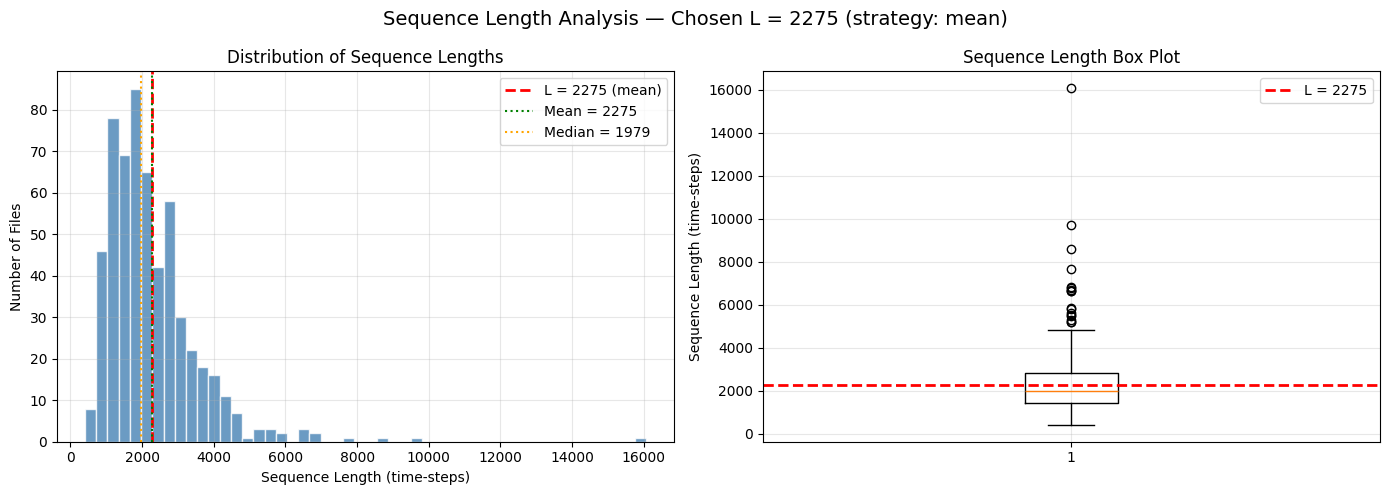


  --- Per-Task Sequence Length Breakdown ---
      count     mean  median     std  min    max
task                                            
        573  2275.38  1979.0  1319.7  405  16071

  --- Per-Group Sequence Length Breakdown ---
                 count     mean  median      std  min    max
group                                                       
Early PD           184  2324.91  1898.5  1668.80  405  16071
Healthy Control    302  2106.55  1882.5   960.45  691   6787
Moderate PD         87  2756.66  2550.0  1445.51  721   9724

✅ SEQUENCE_LENGTH set to: 2275
DL features per time-step: 20


In [9]:
# ============================================================
# 4.3  Data Preprocessing — DYNAMIC SEQUENCE LENGTH CALCULATION
# ============================================================
from sklearn.preprocessing import StandardScaler
from scipy.stats import median_abs_deviation

# ============================================================
# Calculate optimal sequence length from the data
# ============================================================

def calculate_sequence_length(full_df, file_level_df, strategy='mean'):
    """
    Calculate the optimal sequence length based on actual data distribution.
    
    Parameters:
    -----------
    full_df : DataFrame
        The full dataset with all time-step rows.
    file_level_df : DataFrame
        File-level metadata (one row per SVC file).
    strategy : str
        'mean' — use mean sequence length (rounded to nearest integer)
        'median' — use median sequence length
        'mean_plus_std' — use mean + 1 std to capture ~84% of sequences without clipping
    
    Returns:
    --------
    int : The computed sequence length L
    """
    # Count the number of time-steps per SVC file
    seq_lengths = full_df.groupby('file_name').size()
    
    # Only consider files that are in our filtered file-level dataframe
    valid_files = file_level_df['file_name'].values
    seq_lengths = seq_lengths[seq_lengths.index.isin(valid_files)]
    
    print("=" * 60)
    print("  SEQUENCE LENGTH ANALYSIS")
    print("=" * 60)
    print(f"  Number of files analyzed : {len(seq_lengths)}")
    print(f"  Min sequence length      : {seq_lengths.min()}")
    print(f"  Max sequence length      : {seq_lengths.max()}")
    print(f"  Mean sequence length     : {seq_lengths.mean():.2f}")
    print(f"  Median sequence length   : {seq_lengths.median():.2f}")
    print(f"  Std deviation            : {seq_lengths.std():.2f}")
    print(f"  25th percentile          : {seq_lengths.quantile(0.25):.2f}")
    print(f"  75th percentile          : {seq_lengths.quantile(0.75):.2f}")
    print(f"  90th percentile          : {seq_lengths.quantile(0.90):.2f}")
    print(f"  95th percentile          : {seq_lengths.quantile(0.95):.2f}")
    
    if strategy == 'mean':
        L = int(round(seq_lengths.mean()))
    elif strategy == 'median':
        L = int(round(seq_lengths.median()))
    elif strategy == 'mean_plus_std':
        L = int(round(seq_lengths.mean() + seq_lengths.std()))
    else:
        raise ValueError(f"Unknown strategy: {strategy}")
    
    # Report clipping/padding statistics
    n_clipped = (seq_lengths > L).sum()
    n_padded = (seq_lengths < L).sum()
    n_exact = (seq_lengths == L).sum()
    pct_clipped = n_clipped / len(seq_lengths) * 100
    pct_padded = n_padded / len(seq_lengths) * 100
    
    print(f"\n  Strategy: '{strategy}'")
    print(f"  >> Computed L = {L}")
    print(f"  >> Files that will be CLIPPED (len > {L}): {n_clipped} ({pct_clipped:.1f}%)")
    print(f"  >> Files that will be PADDED  (len < {L}): {n_padded} ({pct_padded:.1f}%)")
    print(f"  >> Files with exact length    (len = {L}): {n_exact}")
    
    # Visualize the distribution
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram
    axes[0].hist(seq_lengths.values, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[0].axvline(x=L, color='red', linestyle='--', linewidth=2, label=f'L = {L} ({strategy})')
    axes[0].axvline(x=seq_lengths.mean(), color='green', linestyle=':', linewidth=1.5, label=f'Mean = {seq_lengths.mean():.0f}')
    axes[0].axvline(x=seq_lengths.median(), color='orange', linestyle=':', linewidth=1.5, label=f'Median = {seq_lengths.median():.0f}')
    axes[0].set_xlabel('Sequence Length (time-steps)')
    axes[0].set_ylabel('Number of Files')
    axes[0].set_title('Distribution of Sequence Lengths')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Box plot
    axes[1].boxplot(seq_lengths.values, vert=True)
    axes[1].axhline(y=L, color='red', linestyle='--', linewidth=2, label=f'L = {L}')
    axes[1].set_ylabel('Sequence Length (time-steps)')
    axes[1].set_title('Sequence Length Box Plot')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.suptitle(f'Sequence Length Analysis — Chosen L = {L} (strategy: {strategy})', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Per-task breakdown
    print(f"\n  --- Per-Task Sequence Length Breakdown ---")
    if 'task' in full_df.columns:
        task_lengths = full_df.groupby(['file_name', 'task']).size().reset_index(name='seq_len')
        task_lengths = task_lengths[task_lengths['file_name'].isin(valid_files)]
        task_summary = task_lengths.groupby('task')['seq_len'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
        print(task_summary.round(2).to_string())
    
    # Per-group breakdown
    print(f"\n  --- Per-Group Sequence Length Breakdown ---")
    file_with_len = file_level_df.copy()
    file_with_len['seq_len'] = file_with_len['file_name'].map(seq_lengths)
    group_summary = file_with_len.groupby('group')['seq_len'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    print(group_summary.round(2).to_string())
    
    return L, seq_lengths


# ============================================================
# COMPUTE THE SEQUENCE LENGTH
# ============================================================
# Using all files from the broader file-level df (detection includes all subjects)
SEQUENCE_LENGTH, seq_length_series = calculate_sequence_length(
    full_df, 
    detect_file_df,    # Use detection file_df since it includes ALL subjects
    strategy='mean'    # Use average sequence length as per your requirement
)

print(f"\n✅ SEQUENCE_LENGTH set to: {SEQUENCE_LENGTH}")

# ============================================================
# 4.3 PATH A — Deep Learning Preprocessing (EXPANDED: 20 features)
# ============================================================

DL_RAW_FEATURES = ['x', 'y', 'pressure', 'button_state']  # Original 4

def compute_dl_derived_features(file_data):
    """
    Compute 16 per-time-step derived features from raw handwriting data.
    These are the temporal equivalents of the 16 ML statistical features.
    
    Returns a DataFrame with original 4 + 16 derived = 20 features per time-step.
    """
    df = file_data[DL_RAW_FEATURES + ['timestamp']].copy()
    df = df.sort_values('timestamp').reset_index(drop=True)
    
    dt = df['timestamp'].diff().fillna(1e-6)
    dt = dt.replace(0, 1e-6)
    
    dx = df['x'].diff().fillna(0)
    dy = df['y'].diff().fillna(0)
    
    # ---- Velocity (4 features) ----
    df['vx']       = dx / dt                                    # 1
    df['vy']       = dy / dt                                    # 2
    df['velocity'] = np.sqrt(df['vx']**2 + df['vy']**2)        # 3
    df['displacement'] = np.sqrt(dx**2 + dy**2)                 # 4
    
    # ---- Acceleration (4 features) ----
    dvx = df['vx'].diff().fillna(0)
    dvy = df['vy'].diff().fillna(0)
    df['ax']           = dvx / dt                               # 5
    df['ay']           = dvy / dt                               # 6
    df['acceleration'] = np.sqrt(df['ax']**2 + df['ay']**2)    # 7
    df['velocity_change'] = df['velocity'].diff().fillna(0)     # 8
    
    # ---- Jerk (4 features) ----
    dax = df['ax'].diff().fillna(0)
    day = df['ay'].diff().fillna(0)
    df['jx']   = dax / dt                                       # 9
    df['jy']   = day / dt                                       # 10
    df['jerk'] = np.sqrt(df['jx']**2 + df['jy']**2)            # 11
    df['acceleration_change'] = df['acceleration'].diff().fillna(0)  # 12
    
    # ---- Pressure dynamics (4 features) ----
    df['pressure_change']     = df['pressure'].diff().fillna(0) / dt  # 13
    df['pressure_abs_change'] = df['pressure'].diff().fillna(0).abs() # 14
    df['angle']               = np.arctan2(dy, dx)                     # 15
    df['angular_velocity']    = df['angle'].diff().fillna(0) / dt      # 16
    
    # Replace inf/nan with 0
    df = df.replace([np.inf, -np.inf], 0).fillna(0)
    
    return df


# Define the full 20-feature list
DL_FEATURES = [
    # Original 4 (raw)
    'x', 'y', 'pressure', 'button_state',
    # Velocity-derived (4)
    'vx', 'vy', 'velocity', 'displacement',
    # Acceleration-derived (4)
    'ax', 'ay', 'acceleration', 'velocity_change',
    # Jerk-derived (4)
    'jx', 'jy', 'jerk', 'acceleration_change',
    # Pressure/angular dynamics (4)
    'pressure_change', 'pressure_abs_change', 'angle', 'angular_velocity'
]

print(f"DL features per time-step: {len(DL_FEATURES)}")


def extract_dl_sequence(file_data):
    """
    Extract a time-series matrix with all 20 features for a single SVC file.
    Returns shape (n_timesteps, 20).
    """
    df = compute_dl_derived_features(file_data)
    seq = df[DL_FEATURES].values.astype(np.float32)
    return seq


def pad_or_clip_sequence(seq, target_length=None):
    """
    Clip if longer than target_length, zero-pad if shorter.
    Returns shape (target_length, n_features).
    """
    if target_length is None:
        target_length = SEQUENCE_LENGTH
        
    n_timesteps, n_features = seq.shape
    if n_timesteps >= target_length:
        return seq[:target_length]
    else:
        padded = np.zeros((target_length, n_features), dtype=np.float32)
        padded[:n_timesteps] = seq
        return padded


def prepare_dl_data(full_df, file_df, train_idx, test_idx, label_col):
    """
    Full Path A pipeline for a single fold.
    Now uses 20 features per time-step (4 raw + 16 derived).
    """
    train_files = file_df.iloc[train_idx]['file_name'].values
    test_files = file_df.iloc[test_idx]['file_name'].values

    # Step 1: Extract sequences with all 20 features
    print("  [DL] Extracting sequences with derived features...")
    train_sequences = []
    for fname in train_files:
        fdata = full_df[full_df['file_name'] == fname]
        seq = extract_dl_sequence(fdata)
        train_sequences.append(seq)

    test_sequences = []
    for fname in test_files:
        fdata = full_df[full_df['file_name'] == fname]
        seq = extract_dl_sequence(fdata)
        test_sequences.append(seq)

    # Step 2: Fit Z-score scaler on TRAINING data only
    all_train_points = np.vstack(train_sequences)
    scaler = StandardScaler()
    scaler.fit(all_train_points)

    # Step 3: Scale both train and test
    train_scaled = [scaler.transform(seq) for seq in train_sequences]
    test_scaled = [scaler.transform(seq) for seq in test_sequences]

    # Step 4: Pad/Clip to fixed length
    X_train = np.array([pad_or_clip_sequence(seq, SEQUENCE_LENGTH) for seq in train_scaled])
    X_test = np.array([pad_or_clip_sequence(seq, SEQUENCE_LENGTH) for seq in test_scaled])

    # Step 5: Labels
    y_train = file_df.iloc[train_idx][label_col].values.astype(np.int64)
    y_test = file_df.iloc[test_idx][label_col].values.astype(np.int64)

    print(f"  [DL] Features per time-step: {X_train.shape[2]} (4 raw + 16 derived)")
    print(f"  [DL] Sequence Length L = {SEQUENCE_LENGTH}")
    print(f"  [DL] X_train: {X_train.shape}, X_test: {X_test.shape}")
    print(f"  [DL] y_train dist: {dict(zip(*np.unique(y_train, return_counts=True)))}")
    print(f"  [DL] y_test  dist: {dict(zip(*np.unique(y_test, return_counts=True)))}")

    return X_train, X_test, y_train, y_test

# ============================================================
# 4.3 PATH B — Machine Learning Feature Engineering (CORRECTED)
# ============================================================

def compute_kinematics(file_data):
    """
    Compute velocity, acceleration, jerk from x, y, timestamp.
    Returns the file_data with new kinematic columns.
    """
    df = file_data.sort_values('timestamp').copy()

    dt = df['timestamp'].diff().fillna(1e-6)
    dt = dt.replace(0, 1e-6)

    dx = df['x'].diff().fillna(0)
    dy = df['y'].diff().fillna(0)

    df['vx'] = dx / dt
    df['vy'] = dy / dt
    df['velocity'] = np.sqrt(df['vx']**2 + df['vy']**2)

    dvx = df['vx'].diff().fillna(0)
    dvy = df['vy'].diff().fillna(0)
    df['ax'] = dvx / dt
    df['ay'] = dvy / dt
    df['acceleration'] = np.sqrt(df['ax']**2 + df['ay']**2)

    dax = df['ax'].diff().fillna(0)
    day = df['ay'].diff().fillna(0)
    df['jx'] = dax / dt
    df['jy'] = day / dt
    df['jerk'] = np.sqrt(df['jx']**2 + df['jy']**2)

    return df


def engineer_features(file_data):
    """
    Transform a single SVC file's time-series into a fixed-length feature vector.
    
    Features follow the framework specification:
    - Statistical functionals (mean, median, std, max) for velocity, acceleration, jerk, pressure
    - Spatio-temporal motor hesitation metrics (in-air time, on-surface duration, stroke count)
    """
    df = compute_kinematics(file_data)

    features = {}

    # ----------------------------------------------------------
    # Group 1: Statistical Functionals (mean, median, std, max)
    #          for kinematic derivatives + pressure
    #          4 functionals × 4 signals = 16 features
    # ----------------------------------------------------------
    for col in ['velocity', 'acceleration', 'jerk', 'pressure']:
        vals = df[col].replace([np.inf, -np.inf], np.nan).dropna()
        if len(vals) == 0:
            vals = pd.Series([0.0])

        features[f'{col}_mean']   = vals.mean()
        features[f'{col}_median'] = vals.median()
        features[f'{col}_std']    = vals.std()
        features[f'{col}_max']    = vals.max()

    # ----------------------------------------------------------
    # Group 2: Spatio-Temporal / Motor Hesitation Metrics
    # ----------------------------------------------------------
    total_time = df['timestamp'].max() - df['timestamp'].min()
    features['total_duration'] = total_time if total_time > 0 else 1e-6

    # In-air vs on-surface (button_state: 0 = in-air, 1 = on-surface)
    in_air_mask = df['button_state'] == 0
    on_surface_mask = df['button_state'] == 1

    in_air_time = df.loc[in_air_mask, 'timestamp'].diff().fillna(0).sum()
    on_surface_time = df.loc[on_surface_mask, 'timestamp'].diff().fillna(0).sum()

    features['in_air_time']      = in_air_time
    features['on_surface_time']  = on_surface_time
    features['in_air_ratio']     = in_air_time / features['total_duration']
    features['on_surface_ratio'] = on_surface_time / features['total_duration']

    # Stroke count: transitions from in-air to on-surface
    transitions = df['button_state'].diff().fillna(0)
    features['stroke_count'] = (transitions == 1).sum()

    return features


def prepare_ml_data(full_df, file_df, train_idx, test_idx, label_col):
    """
    Full Path B pipeline for a single fold.
    Returns X_train, X_test, y_train, y_test as numpy arrays.
    """
    train_files = file_df.iloc[train_idx]['file_name'].values
    test_files = file_df.iloc[test_idx]['file_name'].values

    # Step 1: Engineer features for each file
    train_features = []
    for fname in train_files:
        fdata = full_df[full_df['file_name'] == fname]
        feat = engineer_features(fdata)
        feat['file_name'] = fname
        train_features.append(feat)

    test_features = []
    for fname in test_files:
        fdata = full_df[full_df['file_name'] == fname]
        feat = engineer_features(fdata)
        feat['file_name'] = fname
        test_features.append(feat)

    train_feat_df = pd.DataFrame(train_features)
    test_feat_df = pd.DataFrame(test_features)

    # Feature column names (exclude file_name)
    feature_cols = [c for c in train_feat_df.columns if c != 'file_name']

    # Replace inf with NaN, then fill NaN with 0
    train_feat_df[feature_cols] = train_feat_df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
    test_feat_df[feature_cols] = test_feat_df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

    # Step 2: Z-score normalization (fit on train only)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(train_feat_df[feature_cols])
    X_test = scaler.transform(test_feat_df[feature_cols])

    # Step 3: Labels
    y_train = file_df.iloc[train_idx][label_col].values.astype(np.int64)
    y_test = file_df.iloc[test_idx][label_col].values.astype(np.int64)

    print(f"  [ML] Features: {len(feature_cols)}")
    print(f"  [ML] X_train: {X_train.shape}, X_test: {X_test.shape}")
    print(f"  [ML] y_train dist: {dict(zip(*np.unique(y_train, return_counts=True)))}")
    print(f"  [ML] y_test  dist: {dict(zip(*np.unique(y_test, return_counts=True)))}")

    return X_train, X_test, y_train, y_test, feature_cols, scaler
 

In [10]:
# ============================================================
# 4.4  Modeling Methodology
# ============================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# --- Install xgboost if needed ---
try:
    import xgboost as xgb
except ImportError:
    !pip install xgboost
    import xgboost as xgb

# ============================================================
# PATH A: Deep Learning Models (GRU & LSTM)
# ============================================================

class GRUClassifier(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, num_classes=2, dropout=0.3):
        super(GRUClassifier, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True  # ← CHANGE 1: was False
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * 2, num_classes)  # ← CHANGE 2: was hidden_size

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        out, _ = self.gru(x)
        # out shape: (batch, seq_len, hidden_size * 2) due to bidirectional
        # Take the last time step
        out = out[:, -1, :]
        out = self.dropout(out)
        out = self.fc(out)
        return out


class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, num_classes=2, dropout=0.3):
        super(LSTMClassifier, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True  # ← CHANGE 1: was False
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * 2, num_classes)  # ← CHANGE 2: was hidden_size

    def forward(self, x):
        out, (_, _) = self.lstm(x)
        # out shape: (batch, seq_len, hidden_size * 2) due to bidirectional
        # Take the last time step
        out = out[:, -1, :]
        out = self.dropout(out)
        out = self.fc(out)
        return out


def train_dl_model(model, X_train, y_train, X_test, y_test,
                   epochs=100, batch_size=32, lr=1e-3, patience=15):
    """
    Train a PyTorch DL model with class weighting and early stopping.
    Returns the trained model and training history.
    """
    model = model.to(device)

    # Compute class weights
    classes = np.unique(y_train)
    cw = compute_class_weight('balanced', classes=classes, y=y_train)
    class_weights = torch.FloatTensor(cw).to(device)
    print(f"  Class weights: {dict(zip(classes, cw.round(4)))}")

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

    # Create DataLoaders
    train_dataset = TensorDataset(
        torch.FloatTensor(X_train),
        torch.LongTensor(y_train)
    )
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    X_test_tensor = torch.FloatTensor(X_test).to(device)
    y_test_tensor = torch.LongTensor(y_test).to(device)

    # Training loop with early stopping
    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()

        avg_train_loss = epoch_loss / len(train_loader)

        # Validation loss
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_test_tensor)
            val_loss = criterion(val_outputs, y_test_tensor).item()

        scheduler.step(val_loss)

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(val_loss)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1

        if (epoch + 1) % 20 == 0:
            print(f"    Epoch [{epoch+1}/{epochs}] Train Loss: {avg_train_loss:.4f}, Val Loss: {val_loss:.4f}")

        if patience_counter >= patience:
            print(f"    Early stopping at epoch {epoch+1}")
            break

    # Restore best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return model, history


def predict_dl_model(model, X_test):
    """Get predictions and probabilities from a DL model."""
    model.eval()
    with torch.no_grad():
        X_tensor = torch.FloatTensor(X_test).to(device)
        outputs = model(X_tensor)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        preds = np.argmax(probs, axis=1)
    return preds, probs


# ============================================================
# PATH B: Machine Learning Models (RF & XGBoost)
# ============================================================

def train_rf_model(X_train, y_train):
    """Train a Random Forest with class weighting."""
    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    return rf


def train_xgb_model(X_train, y_train):
    """Train XGBoost with class weighting."""
    # Compute scale_pos_weight for binary classification
    classes, counts = np.unique(y_train, return_counts=True)
    if len(classes) == 2:
        scale_pos_weight = counts[0] / counts[1]
    else:
        scale_pos_weight = 1.0

    xgb_model = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    xgb_model.fit(X_train, y_train, verbose=False)
    return xgb_model


def predict_ml_model(model, X_test):
    """Get predictions and probabilities from an ML model."""
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)
    return preds, probs

Using device: cuda


In [11]:
# ============================================================
# 4.5  Performance Metrics
# ============================================================
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

def compute_fold_metrics(y_true, y_pred, y_prob, num_classes=2):
    """
    Compute all metrics for a single fold.
    Returns a dictionary of metric values.
    """
    metrics = {}

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    metrics['confusion_matrix'] = cm

    if num_classes == 2:
        tn, fp, fn, tp = cm.ravel()
        metrics['TP'] = tp
        metrics['TN'] = tn
        metrics['FP'] = fp
        metrics['FN'] = fn

        # Precision, Recall, F1
        metrics['precision'] = precision_score(y_true, y_pred, zero_division=0)
        metrics['recall'] = recall_score(y_true, y_pred, zero_division=0)
        metrics['f1_score'] = f1_score(y_true, y_pred, zero_division=0)

        # Specificity
        metrics['specificity'] = tn / (tn + fp) if (tn + fp) > 0 else 0.0

        # AUC-ROC (use probability of positive class)
        if y_prob is not None and len(np.unique(y_true)) > 1:
            metrics['auc_roc'] = roc_auc_score(y_true, y_prob[:, 1])
        else:
            metrics['auc_roc'] = float('nan')

        # Accuracy
        metrics['accuracy'] = (tp + tn) / (tp + tn + fp + fn)
    else:
        # Macro averages for multi-class
        metrics['precision'] = precision_score(y_true, y_pred, average='macro', zero_division=0)
        metrics['recall'] = recall_score(y_true, y_pred, average='macro', zero_division=0)
        metrics['f1_score'] = f1_score(y_true, y_pred, average='macro', zero_division=0)
        if y_prob is not None and len(np.unique(y_true)) > 1:
            metrics['auc_roc'] = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
        else:
            metrics['auc_roc'] = float('nan')

    return metrics


def print_fold_metrics(metrics, fold_idx, model_name):
    """Pretty-print metrics for a single fold."""
    print(f"\n  --- {model_name} | Fold {fold_idx + 1} ---")
    print(f"  Precision : {metrics['precision']:.4f}")
    print(f"  Recall    : {metrics['recall']:.4f}")
    print(f"  F1-Score  : {metrics['f1_score']:.4f}")
    print(f"  AUC-ROC   : {metrics['auc_roc']:.4f}")
    if 'accuracy' in metrics:
        print(f"  Accuracy  : {metrics['accuracy']:.4f}")
    print(f"  Confusion Matrix:\n{metrics['confusion_matrix']}")


def summarize_cv_results(all_fold_metrics, model_name, task_name):
    """
    Summarize metrics across K folds: report mean ± std.
    Returns a summary dict.
    """
    metric_keys = ['precision', 'recall', 'f1_score', 'auc_roc']
    if 'accuracy' in all_fold_metrics[0]:
        metric_keys.append('accuracy')

    summary = {}
    print(f"\n{'='*60}")
    print(f"  {model_name} | {task_name} | 5-Fold CV Summary")
    print(f"{'='*60}")
    for key in metric_keys:
        values = [m[key] for m in all_fold_metrics if not np.isnan(m[key])]
        mean_val = np.mean(values)
        std_val = np.std(values)
        summary[f'{key}_mean'] = mean_val
        summary[f'{key}_std'] = std_val
        print(f"  {key:12s}: {mean_val:.4f} ± {std_val:.4f}")

    return summary


def plot_confusion_matrices(all_fold_metrics, model_name, task_name, class_names):
    """Plot confusion matrices for all folds."""
    fig, axes = plt.subplots(1, N_SPLITS, figsize=(4 * N_SPLITS, 4))
    for i, metrics in enumerate(all_fold_metrics):
        disp = ConfusionMatrixDisplay(
            confusion_matrix=metrics['confusion_matrix'],
            display_labels=class_names
        )
        disp.plot(ax=axes[i], cmap='Blues', values_format='d')
        axes[i].set_title(f'Fold {i+1}')
    fig.suptitle(f'{model_name} — {task_name}', fontsize=14)
    plt.tight_layout()
    plt.show()


   RUNNING DETECTION TASK: Healthy Control vs PD

############################################################
# Detection — FOLD 1/5
############################################################

  >> Preparing DL data...
  [DL] Extracting sequences with derived features...
  [DL] Features per time-step: 20 (4 raw + 16 derived)
  [DL] Sequence Length L = 2275
  [DL] X_train: (454, 2275, 20), X_test: (119, 2275, 20)
  [DL] y_train dist: {np.int64(0): np.int64(239), np.int64(1): np.int64(215)}
  [DL] y_test  dist: {np.int64(0): np.int64(63), np.int64(1): np.int64(56)}

  >> Preparing ML data...
  [ML] Features: 22
  [ML] X_train: (454, 22), X_test: (119, 22)
  [ML] y_train dist: {np.int64(0): np.int64(239), np.int64(1): np.int64(215)}
  [ML] y_test  dist: {np.int64(0): np.int64(63), np.int64(1): np.int64(56)}

  >> Training GRU...
  Class weights: {np.int64(0): np.float64(0.9498), np.int64(1): np.float64(1.0558)}
    Epoch [20/100] Train Loss: 0.6417, Val Loss: 0.7319
    Early stopping

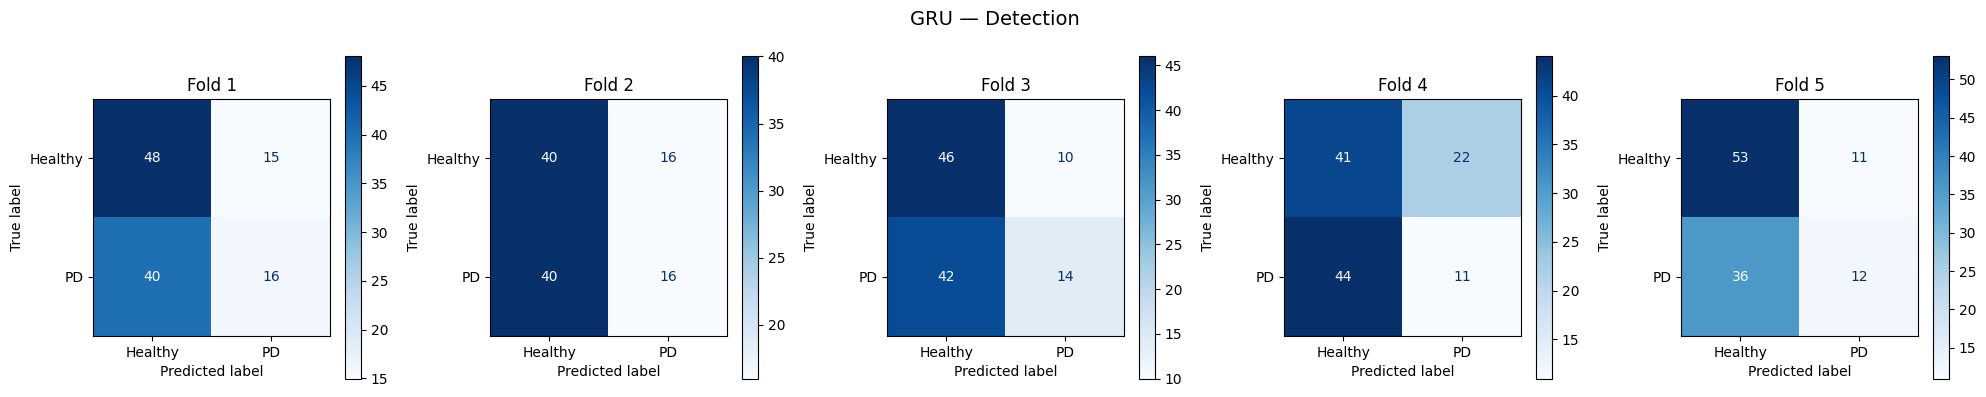


  LSTM | Detection | 5-Fold CV Summary
  precision   : 0.4781 ± 0.0948
  recall      : 0.2447 ± 0.0419
  f1_score    : 0.3234 ± 0.0580
  auc_roc     : 0.4724 ± 0.0326
  accuracy    : 0.5139 ± 0.0569


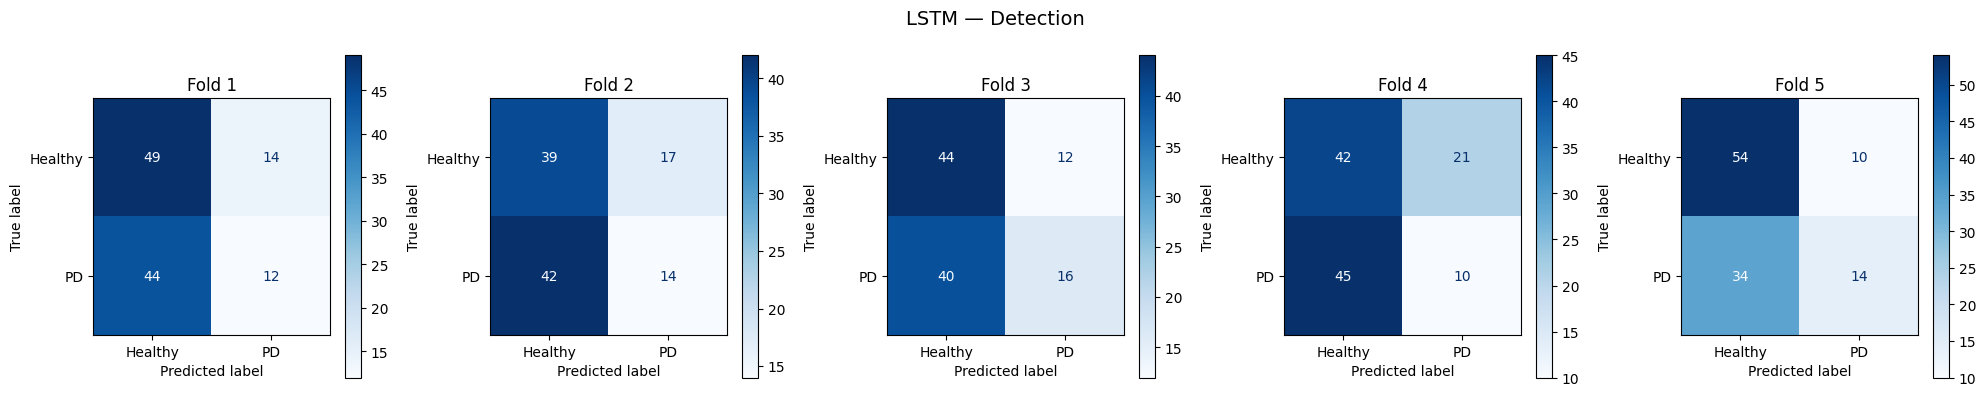


  RF | Detection | 5-Fold CV Summary
  precision   : 0.5638 ± 0.1024
  recall      : 0.5097 ± 0.0911
  f1_score    : 0.5324 ± 0.0871
  auc_roc     : 0.5982 ± 0.0947
  accuracy    : 0.5788 ± 0.0763


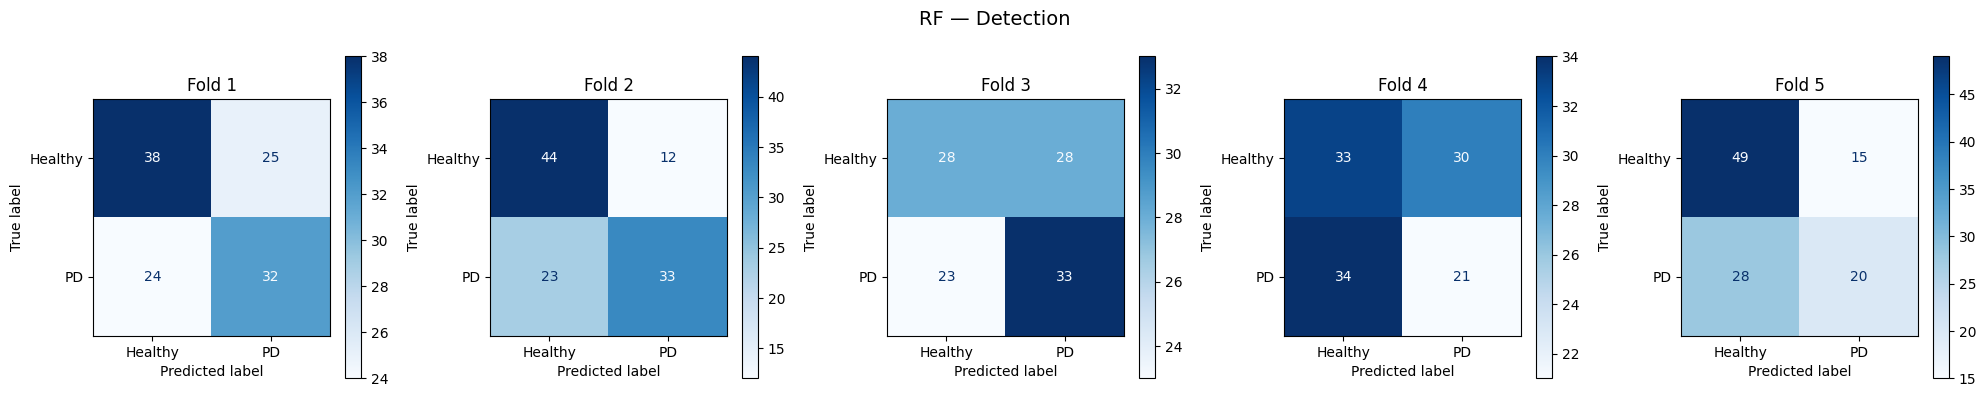


  XGBoost | Detection | 5-Fold CV Summary
  precision   : 0.5461 ± 0.0472
  recall      : 0.5274 ± 0.0224
  f1_score    : 0.5356 ± 0.0281
  auc_roc     : 0.5842 ± 0.0526
  accuracy    : 0.5676 ± 0.0302


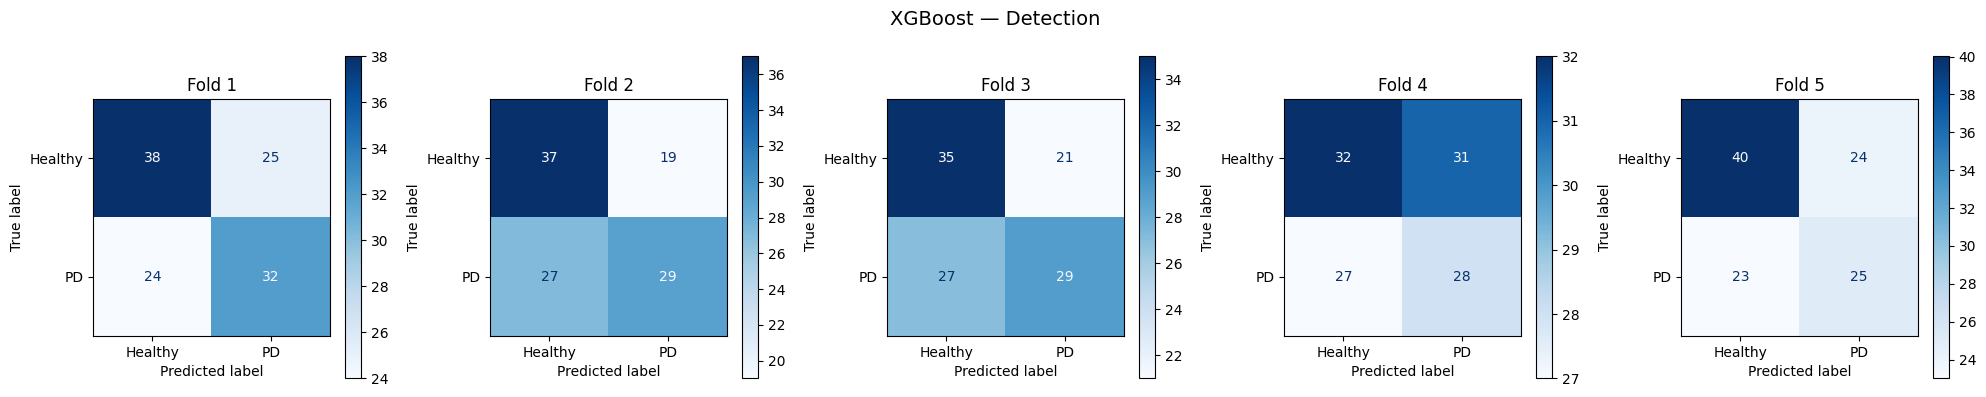


   RUNNING STAGING TASK: Early PD vs Moderate PD

############################################################
# Staging — FOLD 1/5
############################################################

  >> Preparing DL data...
  [DL] Extracting sequences with derived features...
  [DL] Features per time-step: 20 (4 raw + 16 derived)
  [DL] Sequence Length L = 2275
  [DL] X_train: (215, 2275, 20), X_test: (56, 2275, 20)
  [DL] y_train dist: {np.int64(0): np.int64(144), np.int64(1): np.int64(71)}
  [DL] y_test  dist: {np.int64(0): np.int64(40), np.int64(1): np.int64(16)}

  >> Preparing ML data...
  [ML] Features: 22
  [ML] X_train: (215, 22), X_test: (56, 22)
  [ML] y_train dist: {np.int64(0): np.int64(144), np.int64(1): np.int64(71)}
  [ML] y_test  dist: {np.int64(0): np.int64(40), np.int64(1): np.int64(16)}

  >> Training GRU...
  Class weights: {np.int64(0): np.float64(0.7465), np.int64(1): np.float64(1.5141)}
    Early stopping at epoch 16

  --- GRU | Fold 1 ---
  Precision : 0.0667
  Re

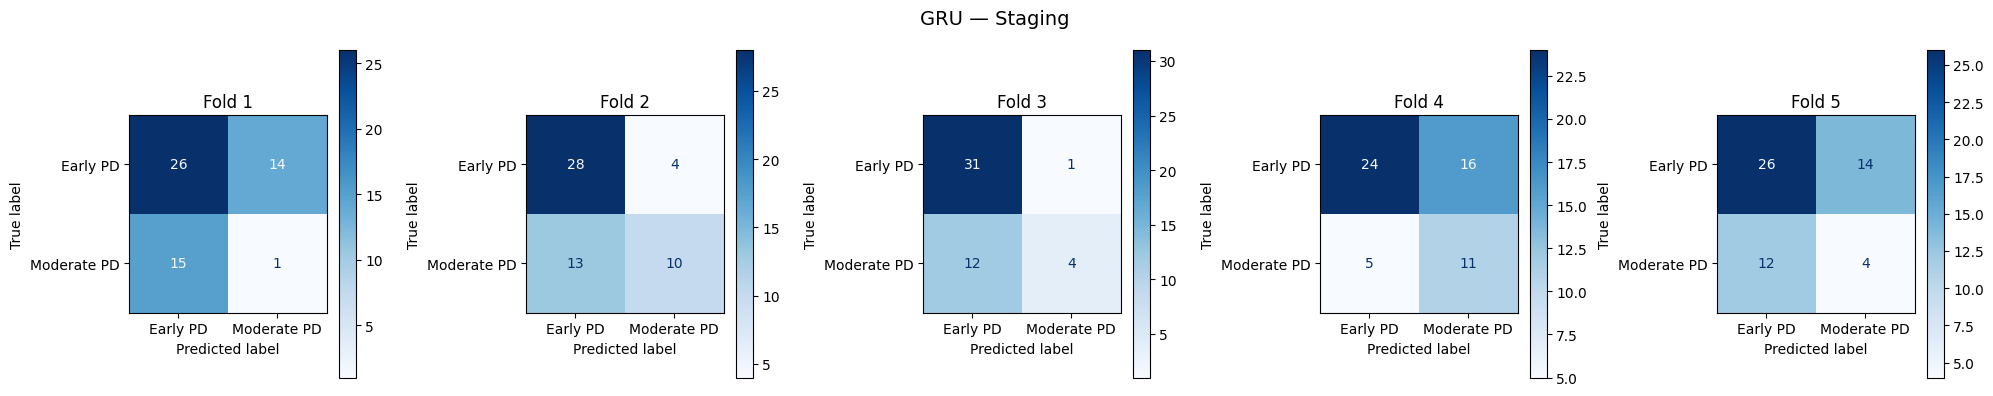


  LSTM | Staging | 5-Fold CV Summary
  precision   : 0.4109 ± 0.3231
  recall      : 0.2832 ± 0.2072
  f1_score    : 0.3319 ± 0.2477
  auc_roc     : 0.5159 ± 0.1373
  accuracy    : 0.6246 ± 0.1292


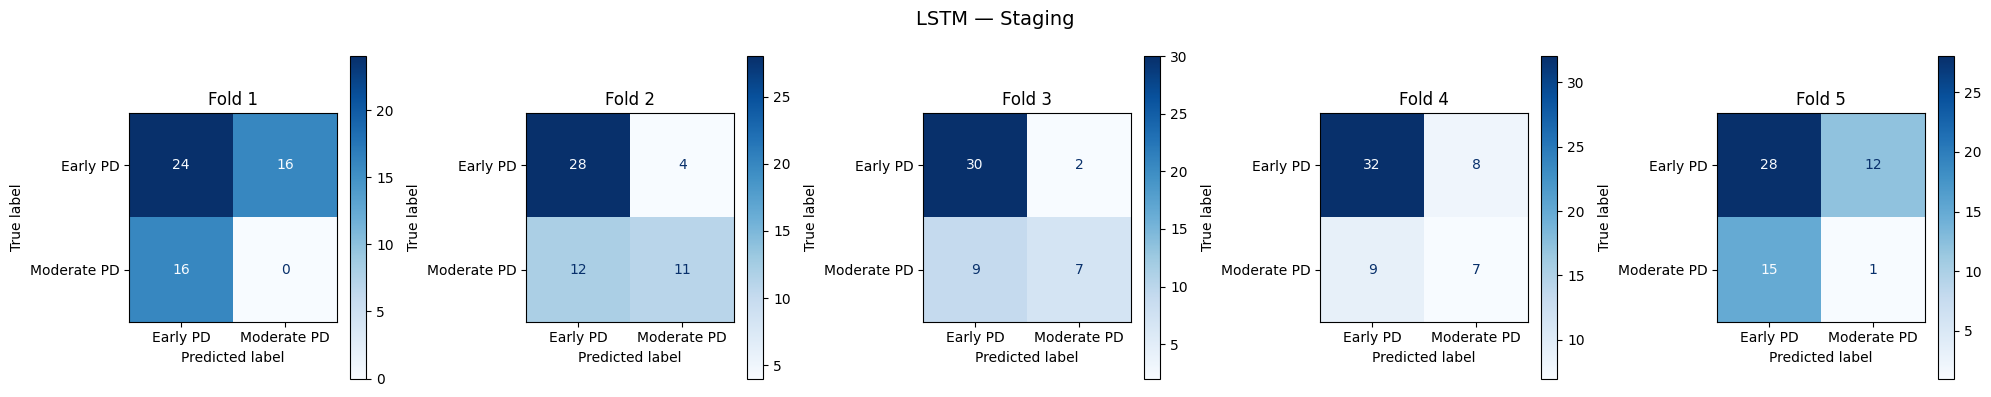


  RF | Staging | 5-Fold CV Summary
  precision   : 0.2667 ± 0.3091
  recall      : 0.0810 ± 0.0825
  f1_score    : 0.1235 ± 0.1296
  auc_roc     : 0.4650 ± 0.1938
  accuracy    : 0.5547 ± 0.1077


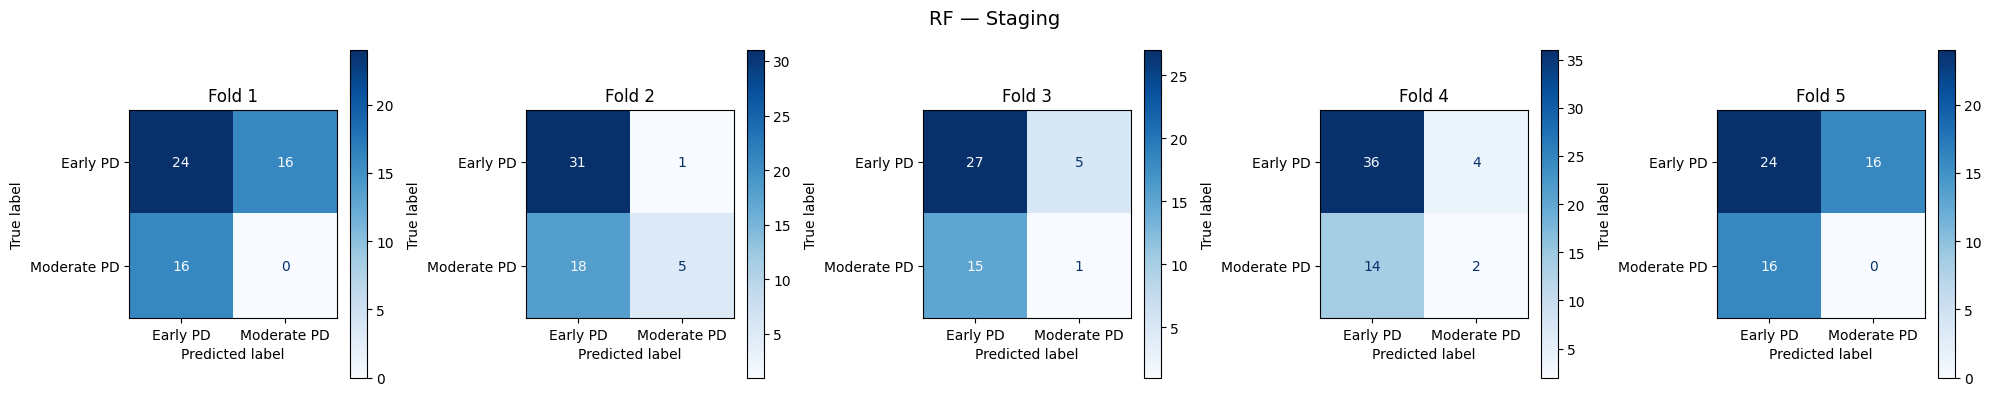


  XGBoost | Staging | 5-Fold CV Summary
  precision   : 0.2801 ± 0.2625
  recall      : 0.1533 ± 0.1285
  f1_score    : 0.1943 ± 0.1751
  auc_roc     : 0.4789 ± 0.1690
  accuracy    : 0.5584 ± 0.1205


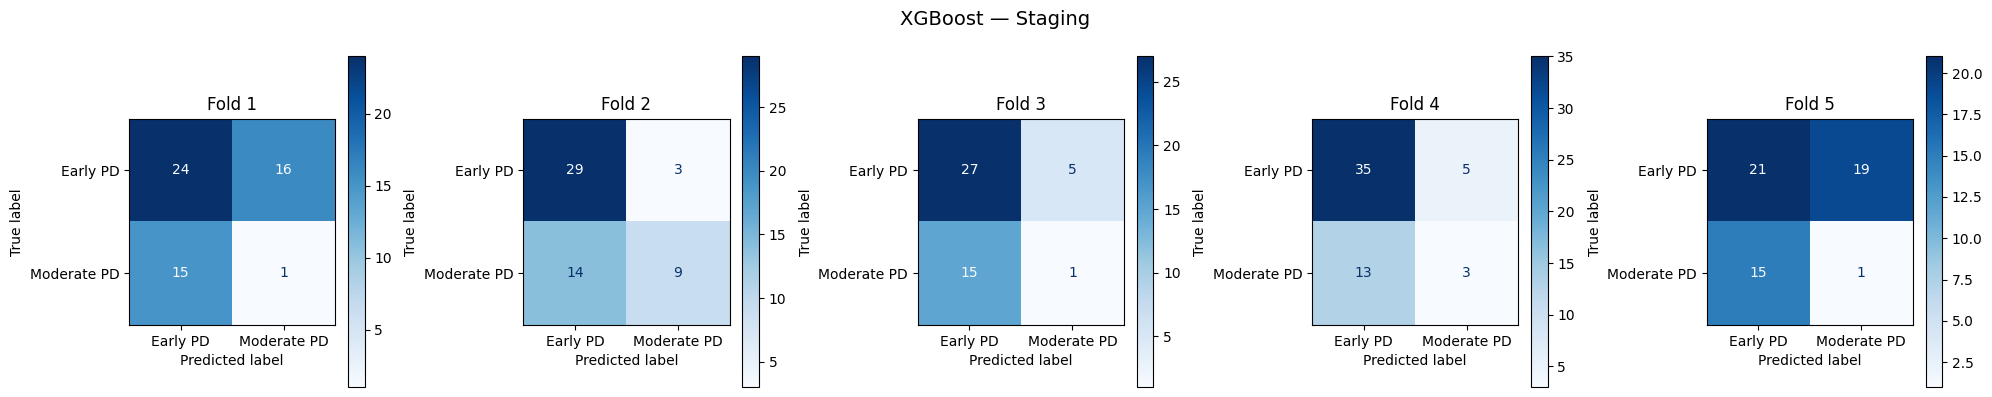

In [12]:
# ============================================================
# MAIN EXPERIMENT LOOP
# ============================================================
import warnings
warnings.filterwarnings('ignore')

# Storage for all results
all_results = {}

# ============================================================
# Helper: run one full task (Detection or Staging)
# ============================================================
def run_experiment(task_name, file_df, label_col, folds, class_names):
    """
    Run the complete experiment pipeline for a given task.
    """
    task_results = {}

    # Storage for each model
    model_fold_metrics = {
        'GRU': [], 'LSTM': [], 'RF': [], 'XGBoost': []
    }
    # Store best fold info for XAI later
    best_fold_info = {
        'GRU': {'best_f1': -1}, 'LSTM': {'best_f1': -1},
        'RF': {'best_f1': -1}, 'XGBoost': {'best_f1': -1}
    }

    input_size = len(DL_FEATURES)  # 4 features
    num_classes = len(class_names)

    for fold_idx, (train_idx, test_idx) in enumerate(folds):
        print(f"\n{'#'*60}")
        print(f"# {task_name} — FOLD {fold_idx + 1}/{N_SPLITS}")
        print(f"{'#'*60}")

        # ---- Path A: Deep Learning Preprocessing ----
        print("\n  >> Preparing DL data...")
        X_train_dl, X_test_dl, y_train_dl, y_test_dl = prepare_dl_data(
            full_df, file_df, train_idx, test_idx, label_col
        )

        # ---- Path B: ML Feature Engineering ----
        print("\n  >> Preparing ML data...")
        X_train_ml, X_test_ml, y_train_ml, y_test_ml, feat_cols, ml_scaler = prepare_ml_data(
            full_df, file_df, train_idx, test_idx, label_col
        )

        # ======== GRU ========
        print("\n  >> Training GRU...")
        gru_model = GRUClassifier(
            input_size=input_size, hidden_size=128,
            num_layers=2, num_classes=num_classes, dropout=0.3
        )
        gru_model, gru_history = train_dl_model(
            gru_model, X_train_dl, y_train_dl, X_test_dl, y_test_dl,
            epochs=100, batch_size=32, lr=1e-3, patience=15
        )
        gru_preds, gru_probs = predict_dl_model(gru_model, X_test_dl)
        gru_metrics = compute_fold_metrics(y_test_dl, gru_preds, gru_probs, num_classes)
        print_fold_metrics(gru_metrics, fold_idx, 'GRU')
        model_fold_metrics['GRU'].append(gru_metrics)

        if gru_metrics['f1_score'] > best_fold_info['GRU']['best_f1']:
            best_fold_info['GRU'] = {
                'best_f1': gru_metrics['f1_score'],
                'fold_idx': fold_idx,
                'model': gru_model,
                'X_test': X_test_dl, 'y_test': y_test_dl,
                'y_pred': gru_preds, 'y_prob': gru_probs,
                'history': gru_history
            }

        # ======== LSTM ========
        print("\n  >> Training LSTM...")
        lstm_model = LSTMClassifier(
            input_size=input_size, hidden_size=128,
            num_layers=2, num_classes=num_classes, dropout=0.3
        )
        lstm_model, lstm_history = train_dl_model(
            lstm_model, X_train_dl, y_train_dl, X_test_dl, y_test_dl,
            epochs=100, batch_size=32, lr=1e-3, patience=15
        )
        lstm_preds, lstm_probs = predict_dl_model(lstm_model, X_test_dl)
        lstm_metrics = compute_fold_metrics(y_test_dl, lstm_preds, lstm_probs, num_classes)
        print_fold_metrics(lstm_metrics, fold_idx, 'LSTM')
        model_fold_metrics['LSTM'].append(lstm_metrics)

        if lstm_metrics['f1_score'] > best_fold_info['LSTM']['best_f1']:
            best_fold_info['LSTM'] = {
                'best_f1': lstm_metrics['f1_score'],
                'fold_idx': fold_idx,
                'model': lstm_model,
                'X_test': X_test_dl, 'y_test': y_test_dl,
                'y_pred': lstm_preds, 'y_prob': lstm_probs,
                'history': lstm_history
            }

        # ======== Random Forest ========
        print("\n  >> Training Random Forest...")
        rf_model = train_rf_model(X_train_ml, y_train_ml)
        rf_preds, rf_probs = predict_ml_model(rf_model, X_test_ml)
        rf_metrics = compute_fold_metrics(y_test_ml, rf_preds, rf_probs, num_classes)
        print_fold_metrics(rf_metrics, fold_idx, 'RF')
        model_fold_metrics['RF'].append(rf_metrics)

        if rf_metrics['f1_score'] > best_fold_info['RF']['best_f1']:
            best_fold_info['RF'] = {
                'best_f1': rf_metrics['f1_score'],
                'fold_idx': fold_idx,
                'model': rf_model,
                'X_train': X_train_ml, 'X_test': X_test_ml,
                'y_train': y_train_ml, 'y_test': y_test_ml,
                'y_pred': rf_preds, 'y_prob': rf_probs,
                'feature_names': feat_cols
            }

        # ======== XGBoost ========
        print("\n  >> Training XGBoost...")
        xgb_model = train_xgb_model(X_train_ml, y_train_ml)
        xgb_preds, xgb_probs = predict_ml_model(xgb_model, X_test_ml)
        xgb_metrics = compute_fold_metrics(y_test_ml, xgb_preds, xgb_probs, num_classes)
        print_fold_metrics(xgb_metrics, fold_idx, 'XGBoost')
        model_fold_metrics['XGBoost'].append(xgb_metrics)

        if xgb_metrics['f1_score'] > best_fold_info['XGBoost']['best_f1']:
            best_fold_info['XGBoost'] = {
                'best_f1': xgb_metrics['f1_score'],
                'fold_idx': fold_idx,
                'model': xgb_model,
                'X_train': X_train_ml, 'X_test': X_test_ml,
                'y_train': y_train_ml, 'y_test': y_test_ml,
                'y_pred': xgb_preds, 'y_prob': xgb_probs,
                'feature_names': feat_cols
            }

    # ---- Summarize all models ----
    print(f"\n\n{'*'*60}")
    print(f"* SUMMARY: {task_name}")
    print(f"{'*'*60}")

    summaries = {}
    for model_name in ['GRU', 'LSTM', 'RF', 'XGBoost']:
        summaries[model_name] = summarize_cv_results(
            model_fold_metrics[model_name], model_name, task_name
        )
        plot_confusion_matrices(
            model_fold_metrics[model_name], model_name, task_name, class_names
        )

    task_results['fold_metrics'] = model_fold_metrics
    task_results['summaries'] = summaries
    task_results['best_fold_info'] = best_fold_info

    return task_results


# ============================================================
# RUN DETECTION TASK
# ============================================================
print("\n" + "=" * 70)
print("   RUNNING DETECTION TASK: Healthy Control vs PD")
print("=" * 70)

detection_results = run_experiment(
    task_name='Detection',
    file_df=detect_file_df,
    label_col='detection_label',
    folds=detection_folds,
    class_names=['Healthy', 'PD']
)

all_results['Detection'] = detection_results

# ============================================================
# RUN STAGING TASK
# ============================================================
print("\n" + "=" * 70)
print("   RUNNING STAGING TASK: Early PD vs Moderate PD")
print("=" * 70)

staging_results = run_experiment(
    task_name='Staging',
    file_df=stage_file_df,
    label_col='staging_label',
    folds=staging_folds,
    class_names=['Early PD', 'Moderate PD']
)

all_results['Staging'] = staging_results


  COMPREHENSIVE RESULTS TABLE
     Task   Model Path       precision          recall        f1_score         auc_roc
Detection     GRU   DL 0.4909 ± 0.0837 0.2543 ± 0.0315 0.3339 ± 0.0432 0.4730 ± 0.0315
Detection    LSTM   DL 0.4781 ± 0.0948 0.2447 ± 0.0419 0.3234 ± 0.0580 0.4724 ± 0.0326
Detection      RF   ML 0.5638 ± 0.1024 0.5097 ± 0.0911 0.5324 ± 0.0871 0.5982 ± 0.0947
Detection XGBoost   ML 0.5461 ± 0.0472 0.5274 ± 0.0224 0.5356 ± 0.0281 0.5842 ± 0.0526
  Staging     GRU   DL 0.4421 ± 0.2802 0.3370 ± 0.2111 0.3466 ± 0.1778 0.4840 ± 0.1485
  Staging    LSTM   DL 0.4109 ± 0.3231 0.2832 ± 0.2072 0.3319 ± 0.2477 0.5159 ± 0.1373
  Staging      RF   ML 0.2667 ± 0.3091 0.0810 ± 0.0825 0.1235 ± 0.1296 0.4650 ± 0.1938
  Staging XGBoost   ML 0.2801 ± 0.2625 0.1533 ± 0.1285 0.1943 ± 0.1751 0.4789 ± 0.1690


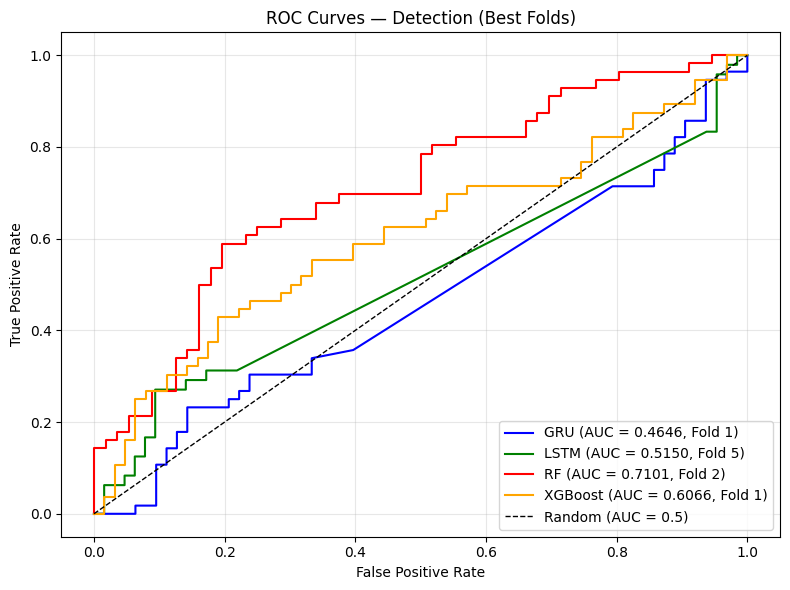

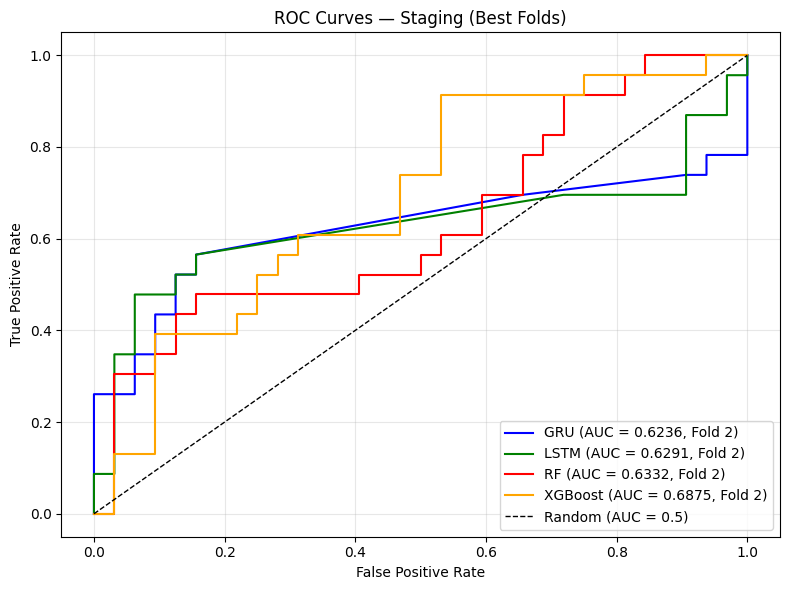

In [13]:
# ============================================================
# 4.5  Final Results Comparison Table
# ============================================================

def create_results_table(all_results):
    """Create a comprehensive results comparison table."""
    rows = []
    for task_name, task_data in all_results.items():
        for model_name, summary in task_data['summaries'].items():
            row = {
                'Task': task_name,
                'Model': model_name,
                'Path': 'DL' if model_name in ['GRU', 'LSTM'] else 'ML'
            }
            for metric in ['precision', 'recall', 'f1_score', 'auc_roc']:
                mean = summary.get(f'{metric}_mean', float('nan'))
                std = summary.get(f'{metric}_std', float('nan'))
                row[f'{metric}'] = f"{mean:.4f} ± {std:.4f}"
            rows.append(row)

    results_df = pd.DataFrame(rows)
    print("\n" + "=" * 90)
    print("  COMPREHENSIVE RESULTS TABLE")
    print("=" * 90)
    print(results_df.to_string(index=False))
    return results_df

results_table = create_results_table(all_results)

# --- ROC Curves ---
from sklearn.metrics import roc_curve, auc

def plot_roc_curves(task_results, task_name):
    """Plot ROC curves for the best fold of each model."""
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    colors = {'GRU': 'blue', 'LSTM': 'green', 'RF': 'red', 'XGBoost': 'orange'}

    for model_name, info in task_results['best_fold_info'].items():
        y_true = info['y_test']
        y_prob = info['y_prob']
        if y_prob is not None and len(np.unique(y_true)) > 1:
            fpr, tpr, _ = roc_curve(y_true, y_prob[:, 1])
            roc_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, color=colors[model_name],
                    label=f'{model_name} (AUC = {roc_auc:.4f}, Fold {info["fold_idx"]+1})')

    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.5)')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curves — {task_name} (Best Folds)')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_roc_curves(detection_results, 'Detection')
plot_roc_curves(staging_results, 'Staging')


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

   XAI — DETECTION TASK

  Integrated Gradients — GRU | Detection
  Best Fold: 1 (F1 = 0.3678)
  [ERROR] IG for GRU: cudnn RNN backward can only be called in training mode

  Integrated Gradients — LSTM | Detection
  Best Fold: 5 (F1 = 0.3889)
  [ERROR] IG for LSTM: cudnn RNN backward can only be called in training mode

  SHAP Analysis — RF | Detection
  Best Fold: 2 (F1 = 0.6535)

  >> SHAP Global Feature Importance (Bar Plot)


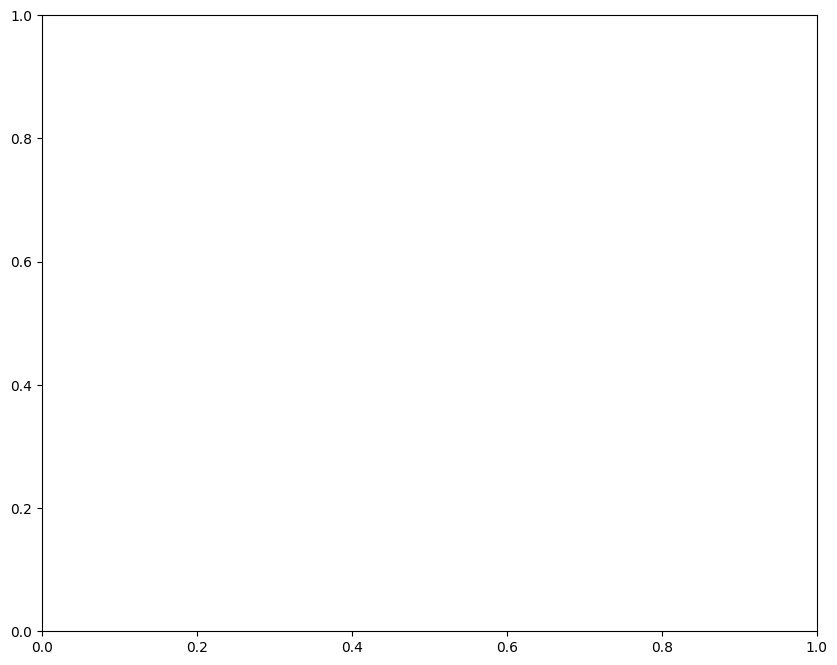

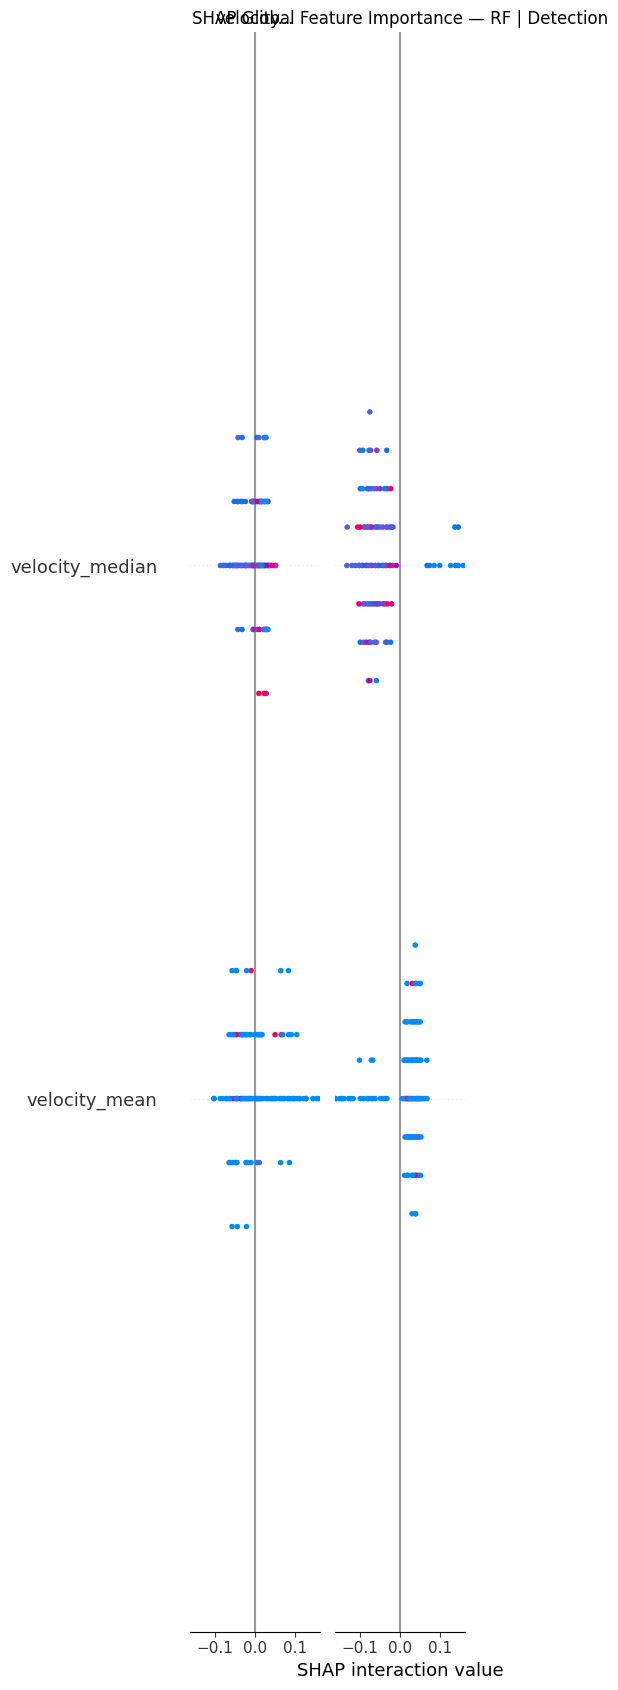


  >> SHAP Summary Plot (Beeswarm)


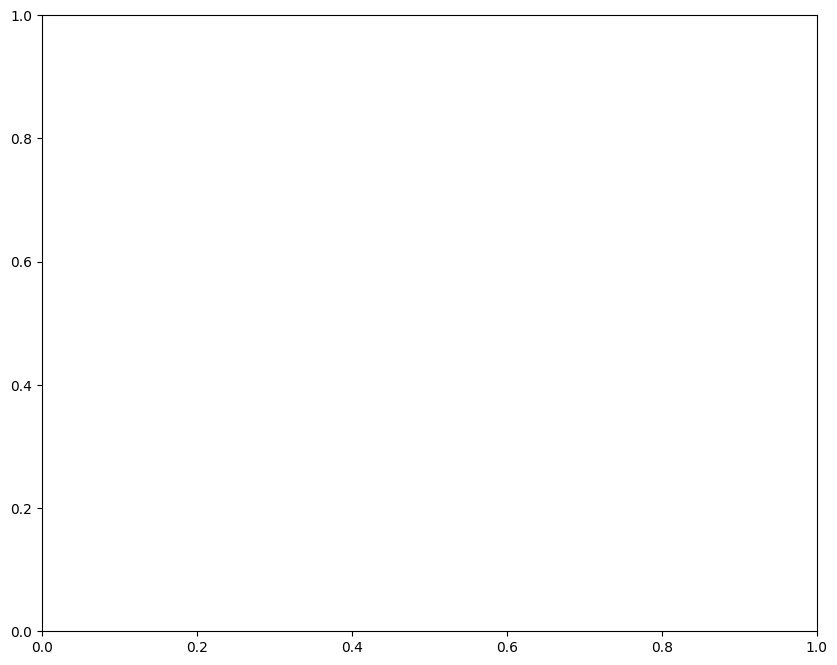

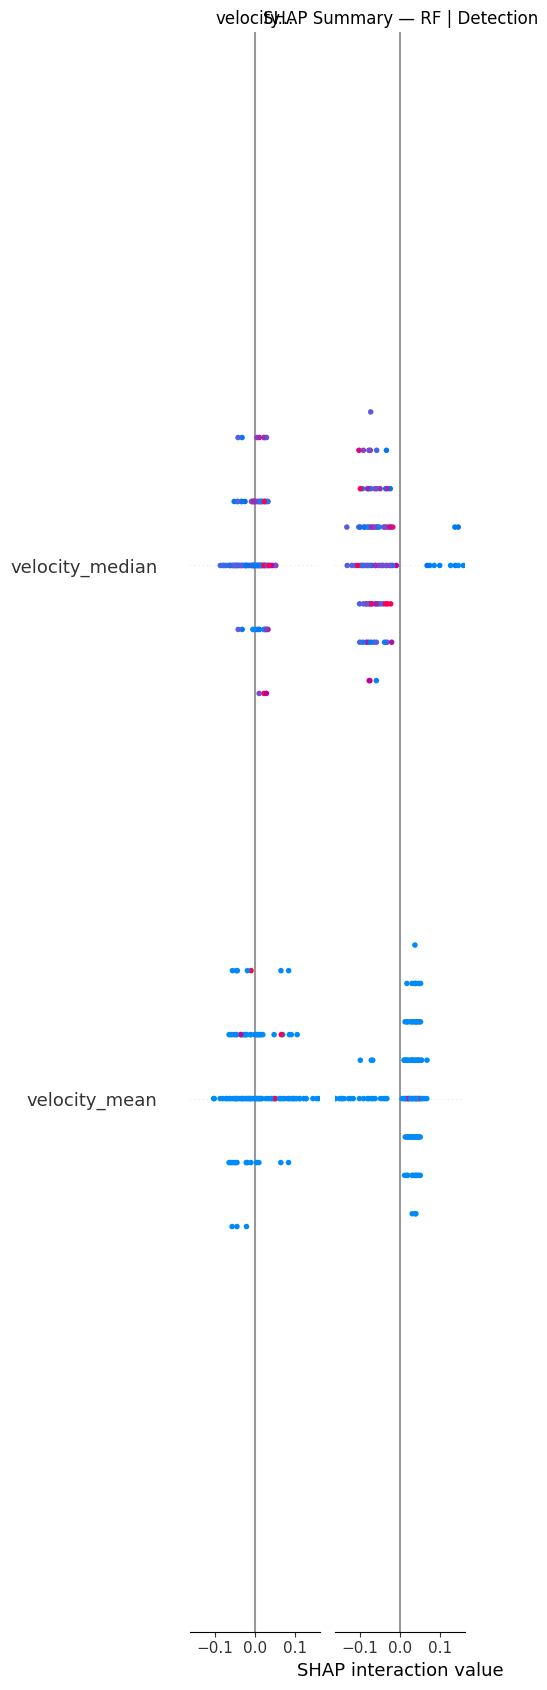


  >> SHAP Local Explanation (first test sample)
  [ERROR] SHAP for RF: In v0.20, force plot now requires the base value as the first parameter! Try shap.plots.force(explainer.expected_value, shap_values) or for multi-output models try shap.plots.force(explainer.expected_value[0], shap_values[..., 0]).

  LIME Analysis — RF | Detection
  Best Fold: 2 (F1 = 0.6535)

  >> LIME Explanation for Test Sample 0
     True: PD, Predicted: Healthy
  [ERROR] LIME for RF: 1

  SHAP Analysis — XGBoost | Detection
  Best Fold: 1 (F1 = 0.5664)

  >> SHAP Global Feature Importance (Bar Plot)


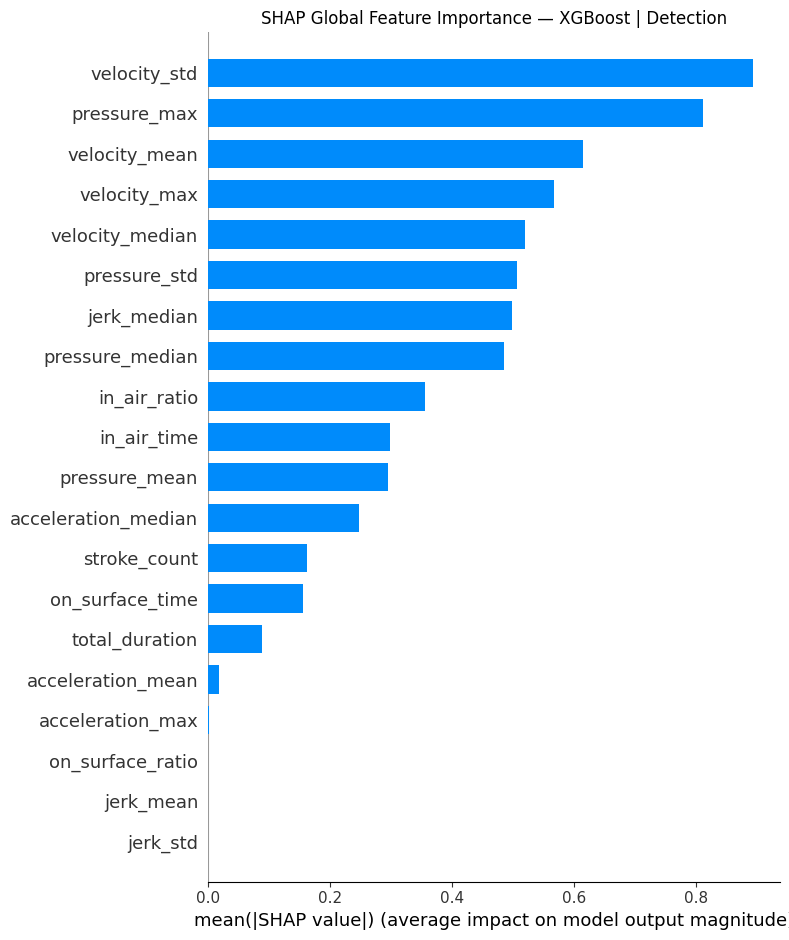


  >> SHAP Summary Plot (Beeswarm)


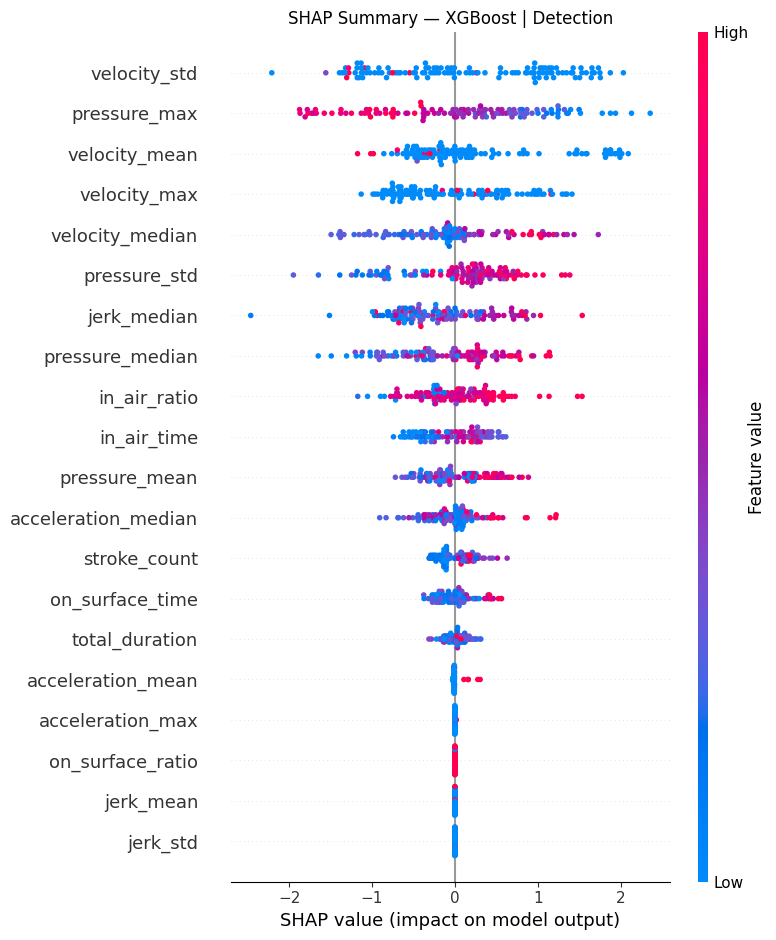


  >> SHAP Local Explanation (first test sample)


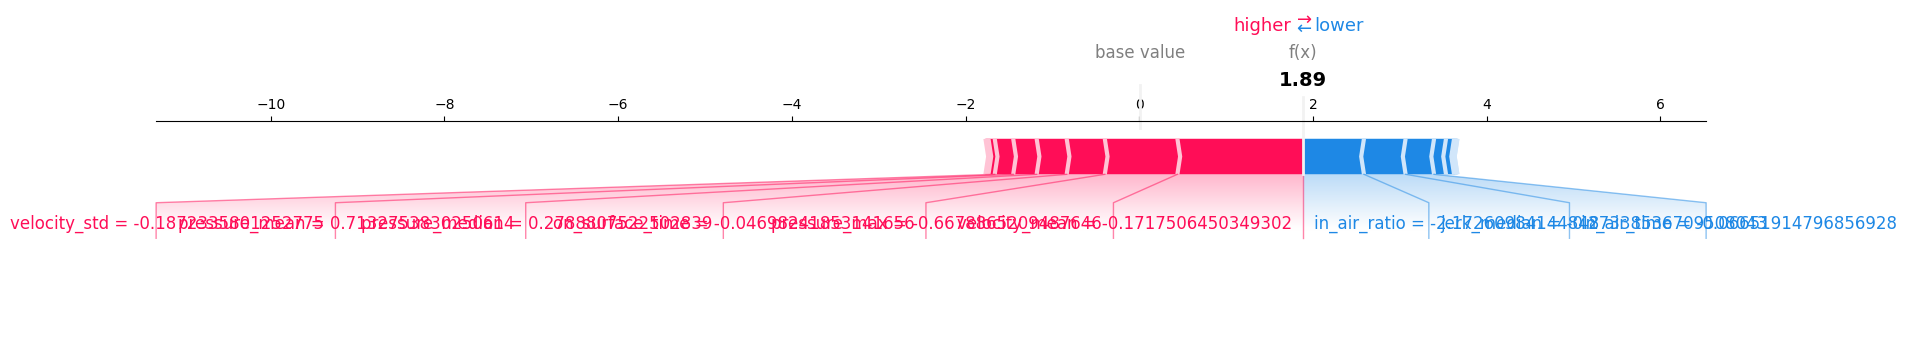


  LIME Analysis — XGBoost | Detection
  Best Fold: 1 (F1 = 0.5664)

  >> LIME Explanation for Test Sample 0
     True: PD, Predicted: PD


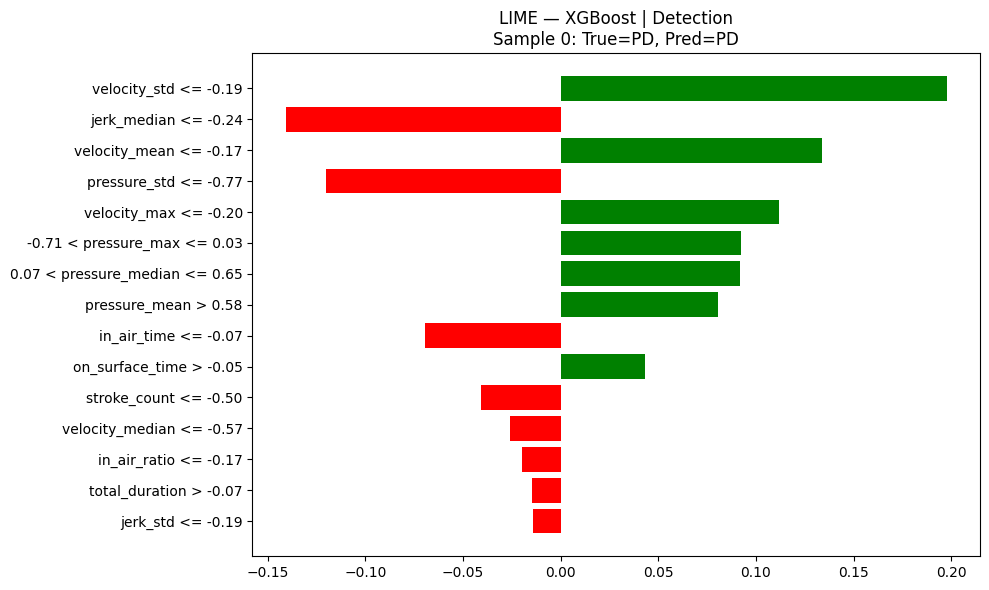


  >> LIME Explanation for Test Sample 1
     True: PD, Predicted: PD


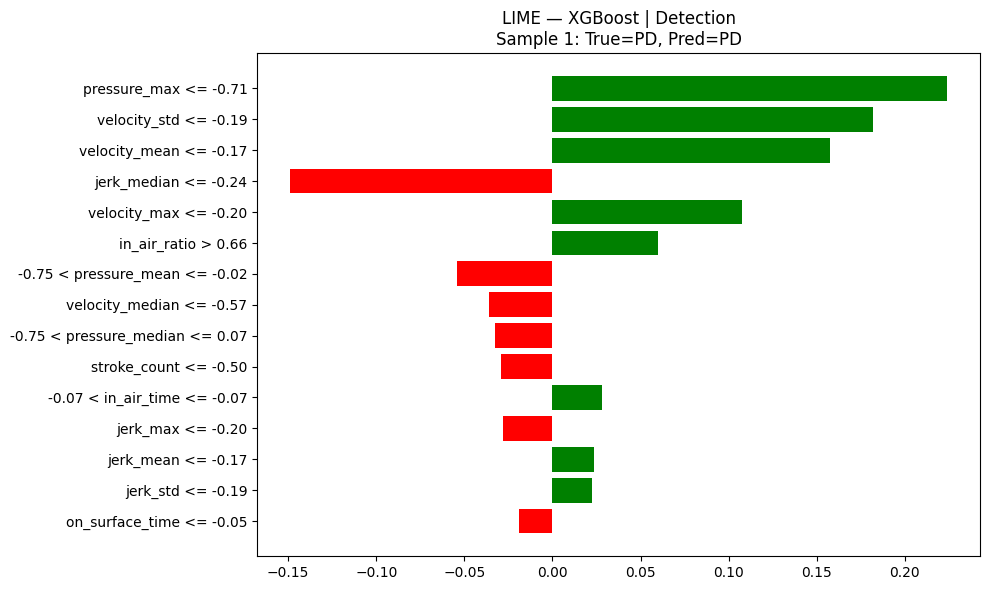


  >> LIME Explanation for Test Sample 2
     True: PD, Predicted: PD


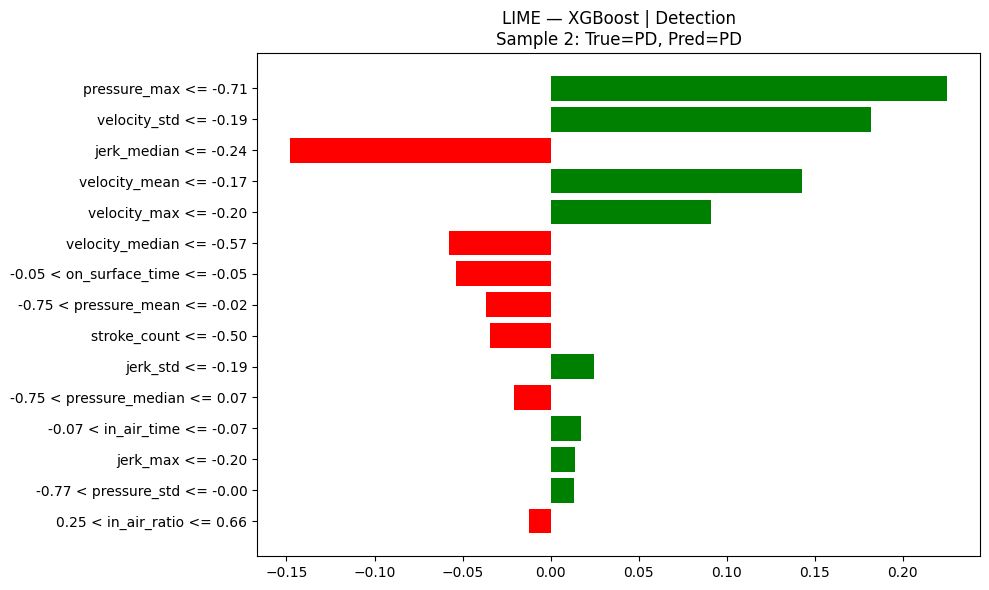


   XAI — STAGING TASK

  Integrated Gradients — GRU | Staging
  Best Fold: 2 (F1 = 0.5405)
  [ERROR] IG for GRU: cudnn RNN backward can only be called in training mode

  Integrated Gradients — LSTM | Staging
  Best Fold: 2 (F1 = 0.5789)
  [ERROR] IG for LSTM: cudnn RNN backward can only be called in training mode

  SHAP Analysis — RF | Staging
  Best Fold: 2 (F1 = 0.3448)

  >> SHAP Global Feature Importance (Bar Plot)


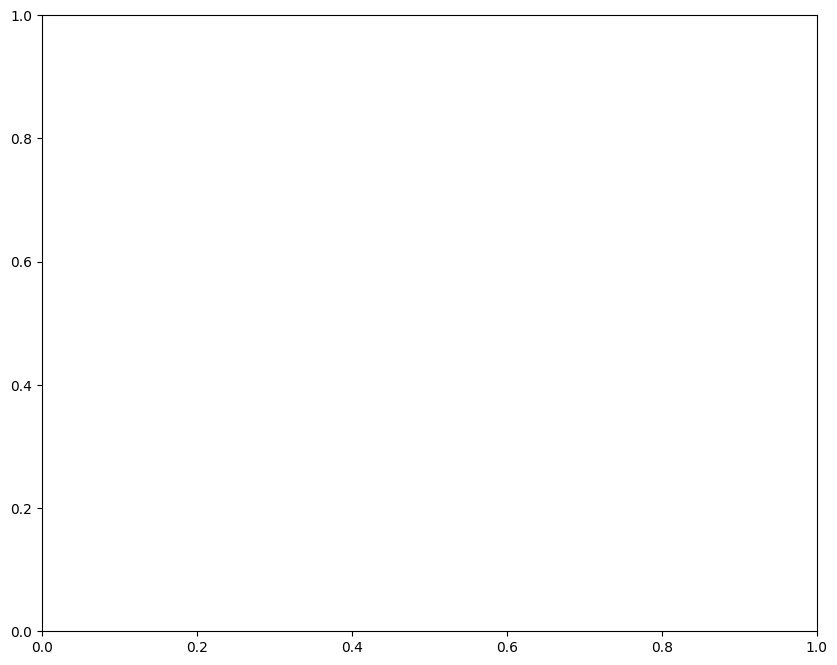

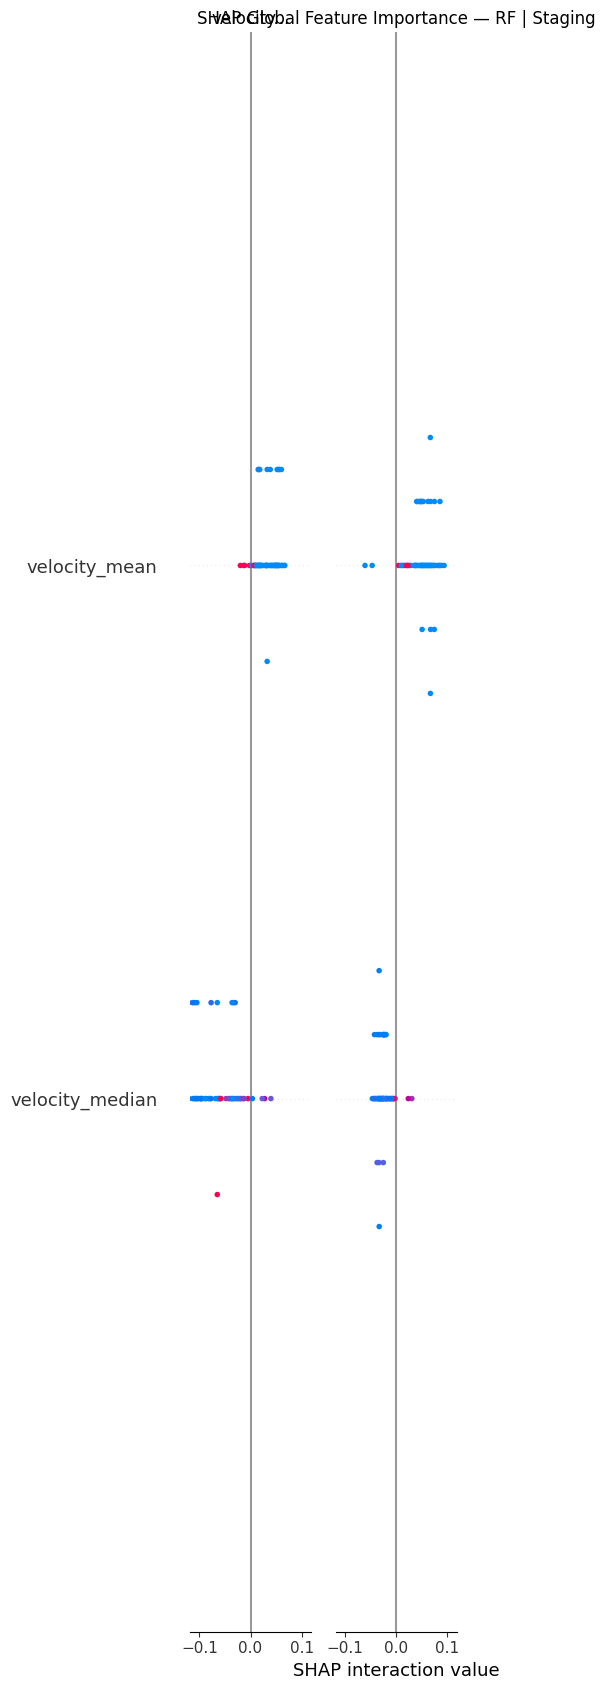


  >> SHAP Summary Plot (Beeswarm)


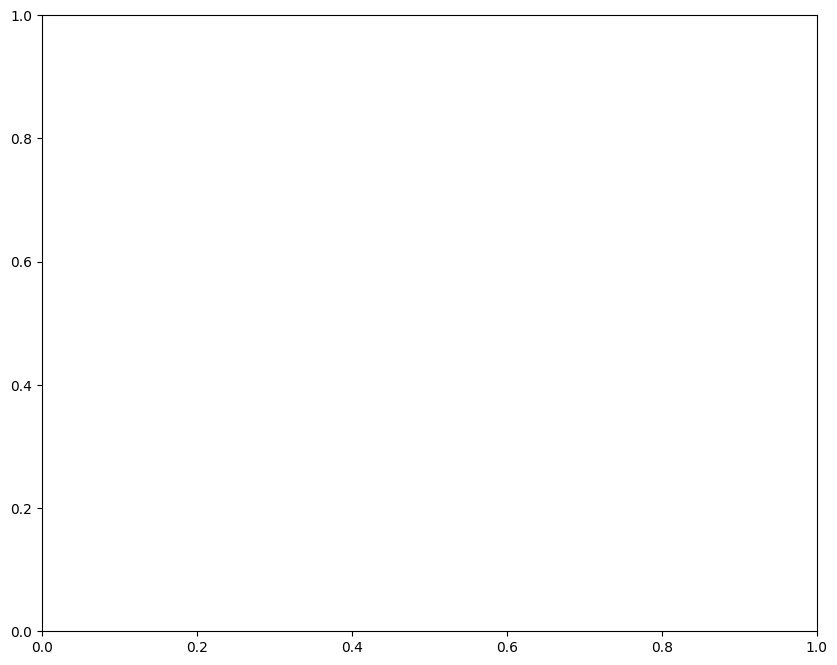

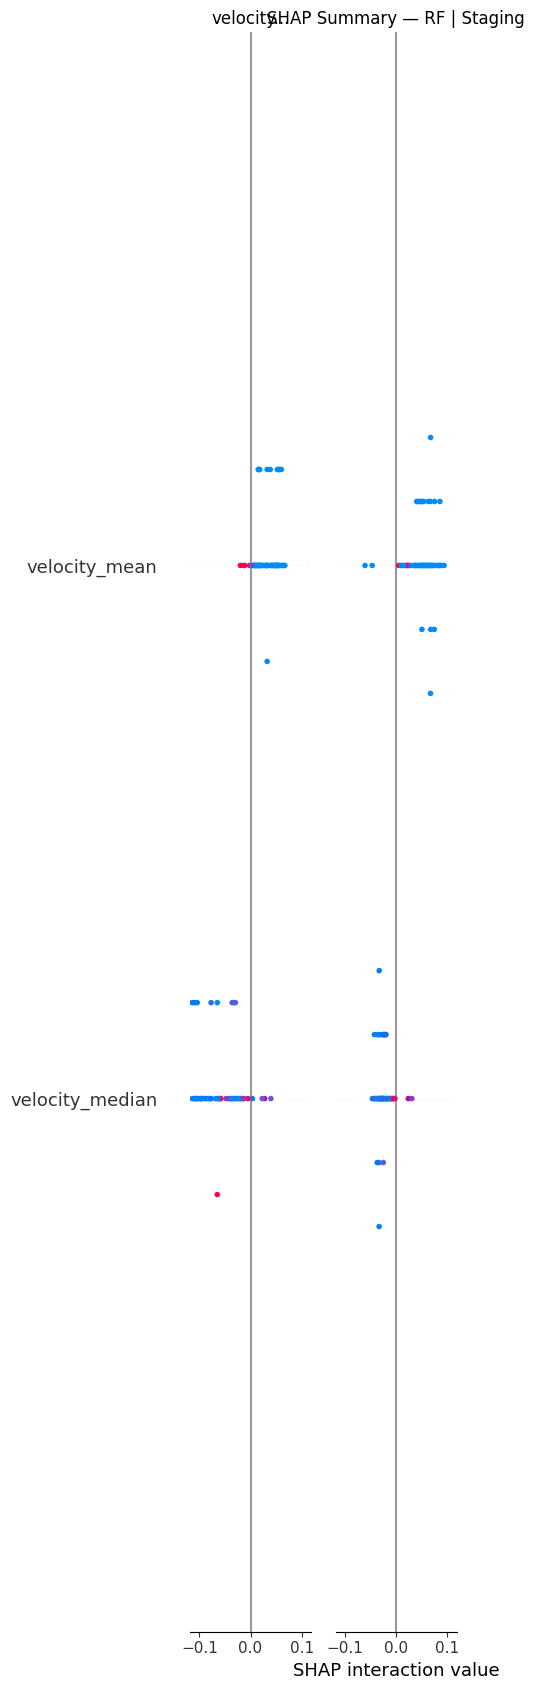


  >> SHAP Local Explanation (first test sample)
  [ERROR] SHAP for RF: In v0.20, force plot now requires the base value as the first parameter! Try shap.plots.force(explainer.expected_value, shap_values) or for multi-output models try shap.plots.force(explainer.expected_value[0], shap_values[..., 0]).

  LIME Analysis — RF | Staging
  Best Fold: 2 (F1 = 0.3448)

  >> LIME Explanation for Test Sample 0
     True: Early PD, Predicted: Early PD
  [ERROR] LIME for RF: 1

  SHAP Analysis — XGBoost | Staging
  Best Fold: 2 (F1 = 0.5143)

  >> SHAP Global Feature Importance (Bar Plot)


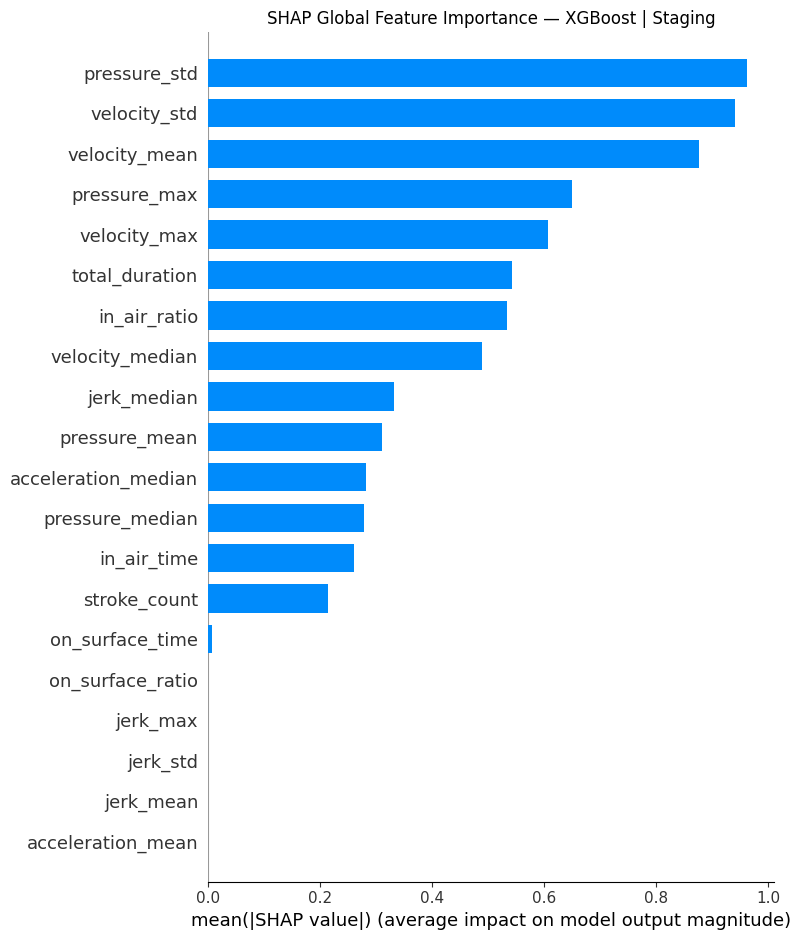


  >> SHAP Summary Plot (Beeswarm)


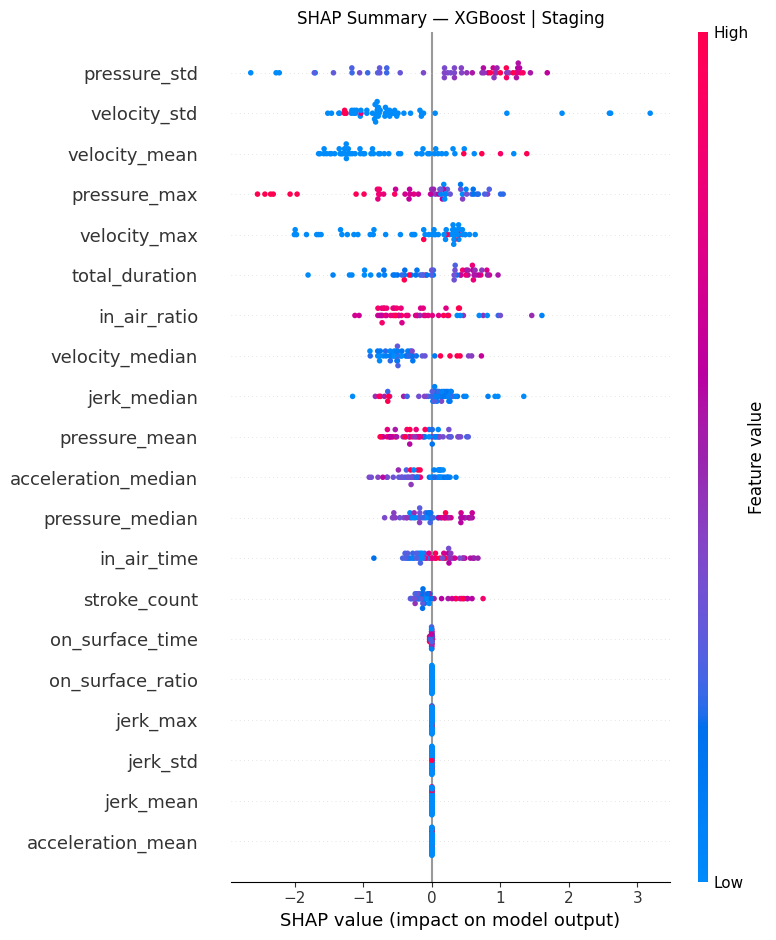


  >> SHAP Local Explanation (first test sample)


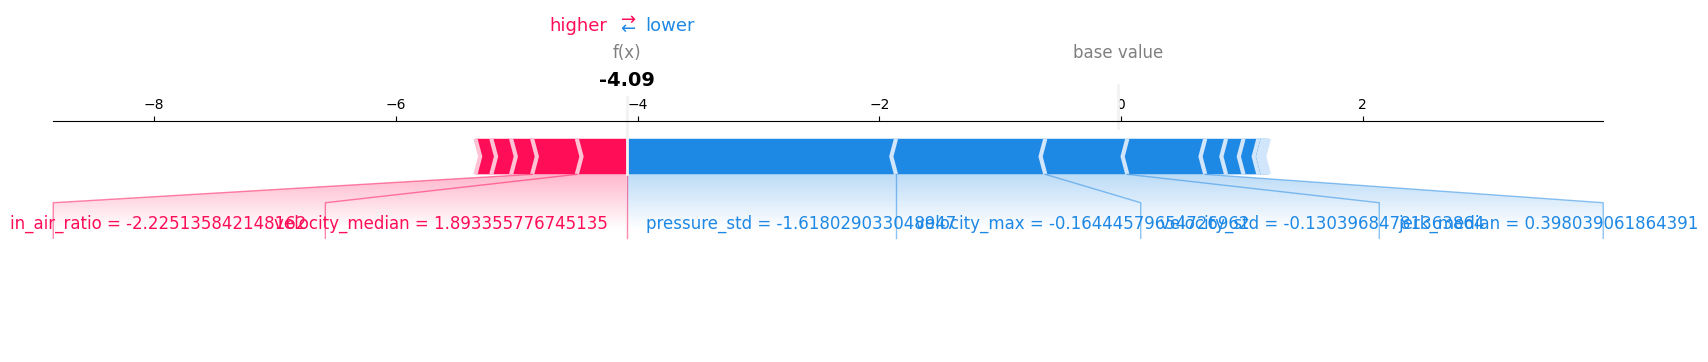


  LIME Analysis — XGBoost | Staging
  Best Fold: 2 (F1 = 0.5143)

  >> LIME Explanation for Test Sample 0
     True: Early PD, Predicted: Early PD
  [ERROR] LIME for XGBoost: 1


In [14]:
# ============================================================
# 4.6  Model Interpretability (XAI)
# ============================================================

# Install required packages
!pip install shap lime captum -q

import shap
import lime
import lime.lime_tabular
from captum.attr import IntegratedGradients

# ============================================================
# PATH A: Integrated Gradients for GRU/LSTM
# ============================================================

def run_integrated_gradients(task_results, model_name, task_name, class_names):
    """
    Apply Integrated Gradients to the best-performing DL model fold.
    Produces temporal saliency heatmaps.
    """
    info = task_results['best_fold_info'][model_name]
    model = info['model']
    X_test = info['X_test']
    y_test = info['y_test']
    y_pred = info['y_pred']

    print(f"\n{'='*60}")
    print(f"  Integrated Gradients — {model_name} | {task_name}")
    print(f"  Best Fold: {info['fold_idx'] + 1} (F1 = {info['best_f1']:.4f})")
    print(f"{'='*60}")

    model.eval()
    model.to(device)

    # Wrap model for captum
    ig = IntegratedGradients(model)

    # Select a subset of test samples for visualization
    n_samples = min(20, len(X_test))
    sample_indices = np.random.RandomState(42).choice(len(X_test), n_samples, replace=False)

    all_attributions = []

    for idx in sample_indices:
        input_tensor = torch.FloatTensor(X_test[idx:idx+1]).to(device)
        input_tensor.requires_grad = True

        target_class = int(y_pred[idx])
        baseline = torch.zeros_like(input_tensor).to(device)

        attribution = ig.attribute(
            input_tensor, baselines=baseline,
            target=target_class, n_steps=50
        )
        all_attributions.append(attribution.squeeze().cpu().detach().numpy())

    attributions = np.array(all_attributions)  # (n_samples, seq_len, n_features)

    # --- Average attribution magnitude across samples ---
    avg_attribution = np.mean(np.abs(attributions), axis=0)  # (seq_len, n_features)

    feature_names = DL_FEATURES

    # --- Temporal Saliency Heatmap ---
    fig, ax = plt.subplots(figsize=(14, 4))
    im = ax.imshow(avg_attribution.T, aspect='auto', cmap='hot', interpolation='nearest')
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Feature')
    ax.set_yticks(range(len(feature_names)))
    ax.set_yticklabels(feature_names)
    ax.set_title(f'Temporal Saliency Heatmap — {model_name} | {task_name}\n'
                 f'(Avg |Attribution| over {n_samples} test samples, Best Fold {info["fold_idx"]+1})')
    plt.colorbar(im, ax=ax, label='Mean |Attribution|')
    plt.tight_layout()
    plt.show()

    # --- Per-feature attribution over time ---
    fig, axes = plt.subplots(len(feature_names), 1, figsize=(14, 3 * len(feature_names)), sharex=True)
    for i, feat in enumerate(feature_names):
        axes[i].plot(avg_attribution[:, i], color='crimson', lw=1.5)
        axes[i].fill_between(range(avg_attribution.shape[0]), avg_attribution[:, i], alpha=0.3, color='crimson')
        axes[i].set_ylabel(f'|Attr| — {feat}')
        axes[i].grid(alpha=0.3)
    axes[-1].set_xlabel('Time Step')
    fig.suptitle(f'Per-Feature Temporal Attribution — {model_name} | {task_name}', fontsize=14)
    plt.tight_layout()
    plt.show()

    # --- Sample-level heatmaps for correctly classified samples ---
    correct_mask = y_pred[sample_indices] == y_test[sample_indices]
    correct_indices = np.where(correct_mask)[0]

    if len(correct_indices) >= 2:
        n_show = min(4, len(correct_indices))
        fig, axes = plt.subplots(n_show, 1, figsize=(14, 3 * n_show))
        if n_show == 1:
            axes = [axes]
        for i in range(n_show):
            si = correct_indices[i]
            true_label = class_names[y_test[sample_indices[si]]]
            im = axes[i].imshow(attributions[si].T, aspect='auto', cmap='hot', interpolation='nearest')
            axes[i].set_ylabel('Feature')
            axes[i].set_yticks(range(len(feature_names)))
            axes[i].set_yticklabels(feature_names)
            axes[i].set_title(f'Sample {sample_indices[si]} — True: {true_label}')
            plt.colorbar(im, ax=axes[i])
        axes[-1].set_xlabel('Time Step')
        fig.suptitle(f'Individual Saliency Maps — {model_name} | {task_name}', fontsize=14)
        plt.tight_layout()
        plt.show()

    return attributions


# ============================================================
# PATH B: SHAP & LIME for RF/XGBoost
# ============================================================

def run_shap_analysis(task_results, model_name, task_name, class_names):
    """
    Apply SHAP to the best-performing ML model fold.
    Produces global and local feature importance plots.
    """
    info = task_results['best_fold_info'][model_name]
    model = info['model']
    X_test = info['X_test']
    X_train = info['X_train']
    y_test = info['y_test']
    y_pred = info['y_pred']
    feature_names = info['feature_names']

    print(f"\n{'='*60}")
    print(f"  SHAP Analysis — {model_name} | {task_name}")
    print(f"  Best Fold: {info['fold_idx'] + 1} (F1 = {info['best_f1']:.4f})")
    print(f"{'='*60}")

    # Use appropriate SHAP explainer
    if model_name == 'RF':
        explainer = shap.TreeExplainer(model)
    elif model_name == 'XGBoost':
        explainer = shap.TreeExplainer(model)
    else:
        # Fallback to KernelExplainer
        background = shap.sample(pd.DataFrame(X_train, columns=feature_names), 100)
        explainer = shap.KernelExplainer(model.predict_proba, background)

    shap_values = explainer.shap_values(X_test)

    # --- Global Feature Importance (Bar Plot) ---
    print("\n  >> SHAP Global Feature Importance (Bar Plot)")
    fig, ax = plt.subplots(figsize=(10, 8))
    if isinstance(shap_values, list):
        # For binary: use SHAP values for the positive class (index 1)
        shap.summary_plot(shap_values[1], X_test, feature_names=feature_names,
                          plot_type="bar", show=False, max_display=20)
    else:
        shap.summary_plot(shap_values, X_test, feature_names=feature_names,
                          plot_type="bar", show=False, max_display=20)
    plt.title(f'SHAP Global Feature Importance — {model_name} | {task_name}')
    plt.tight_layout()
    plt.show()

    # --- SHAP Summary Plot (Beeswarm) ---
    print("\n  >> SHAP Summary Plot (Beeswarm)")
    fig, ax = plt.subplots(figsize=(10, 8))
    if isinstance(shap_values, list):
        shap.summary_plot(shap_values[1], X_test, feature_names=feature_names,
                          show=False, max_display=20)
    else:
        shap.summary_plot(shap_values, X_test, feature_names=feature_names,
                          show=False, max_display=20)
    plt.title(f'SHAP Summary — {model_name} | {task_name}')
    plt.tight_layout()
    plt.show()

    # --- Local Explanation (Force Plot for a single sample) ---
    print("\n  >> SHAP Local Explanation (first test sample)")
    if isinstance(shap_values, list):
        shap.force_plot(
            explainer.expected_value[1],
            shap_values[1][0],
            pd.DataFrame(X_test, columns=feature_names).iloc[0],
            matplotlib=True, show=True
        )
    else:
        shap.force_plot(
            explainer.expected_value,
            shap_values[0],
            pd.DataFrame(X_test, columns=feature_names).iloc[0],
            matplotlib=True, show=True
        )

    return shap_values


def run_lime_analysis(task_results, model_name, task_name, class_names):
    """
    Apply LIME to the best-performing ML model fold.
    Produces local interpretability plots.
    """
    info = task_results['best_fold_info'][model_name]
    model = info['model']
    X_train = info['X_train']
    X_test = info['X_test']
    y_test = info['y_test']
    y_pred = info['y_pred']
    feature_names = info['feature_names']

    print(f"\n{'='*60}")
    print(f"  LIME Analysis — {model_name} | {task_name}")
    print(f"  Best Fold: {info['fold_idx'] + 1} (F1 = {info['best_f1']:.4f})")
    print(f"{'='*60}")

    # Create LIME explainer
    lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train,
        feature_names=feature_names,
        class_names=class_names,
        mode='classification',
        random_state=RANDOM_STATE
    )

    # Explain a few samples
    n_explain = min(3, len(X_test))
    for i in range(n_explain):
        true_label = class_names[y_test[i]]
        pred_label = class_names[y_pred[i]]

        print(f"\n  >> LIME Explanation for Test Sample {i}")
        print(f"     True: {true_label}, Predicted: {pred_label}")

        explanation = lime_explainer.explain_instance(
            X_test[i],
            model.predict_proba,
            num_features=15,
            top_labels=1
        )

        # Show as matplotlib figure
        fig = explanation.as_pyplot_figure()
        fig.set_size_inches(10, 6)
        plt.title(f'LIME — {model_name} | {task_name}\nSample {i}: True={true_label}, Pred={pred_label}')
        plt.tight_layout()
        plt.show()

    return lime_explainer


# ============================================================
# RUN XAI FOR ALL MODELS — DETECTION TASK
# ============================================================
print("\n" + "=" * 70)
print("   XAI — DETECTION TASK")
print("=" * 70)

# DL Models
for dl_model_name in ['GRU', 'LSTM']:
    try:
        run_integrated_gradients(detection_results, dl_model_name, 'Detection', ['Healthy', 'PD'])
    except Exception as e:
        print(f"  [ERROR] IG for {dl_model_name}: {e}")

# ML Models
for ml_model_name in ['RF', 'XGBoost']:
    try:
        run_shap_analysis(detection_results, ml_model_name, 'Detection', ['Healthy', 'PD'])
    except Exception as e:
        print(f"  [ERROR] SHAP for {ml_model_name}: {e}")

    try:
        run_lime_analysis(detection_results, ml_model_name, 'Detection', ['Healthy', 'PD'])
    except Exception as e:
        print(f"  [ERROR] LIME for {ml_model_name}: {e}")

# ============================================================
# RUN XAI FOR ALL MODELS — STAGING TASK
# ============================================================
print("\n" + "=" * 70)
print("   XAI — STAGING TASK")
print("=" * 70)

# DL Models
for dl_model_name in ['GRU', 'LSTM']:
    try:
        run_integrated_gradients(staging_results, dl_model_name, 'Staging', ['Early PD', 'Moderate PD'])
    except Exception as e:
        print(f"  [ERROR] IG for {dl_model_name}: {e}")

# ML Models
for ml_model_name in ['RF', 'XGBoost']:
    try:
        run_shap_analysis(staging_results, ml_model_name, 'Staging', ['Early PD', 'Moderate PD'])
    except Exception as e:
        print(f"  [ERROR] SHAP for {ml_model_name}: {e}")

    try:
        run_lime_analysis(staging_results, ml_model_name, 'Staging', ['Early PD', 'Moderate PD'])
    except Exception as e:
        print(f"  [ERROR] LIME for {ml_model_name}: {e}")

In [15]:
# ============================================================
# FINAL: Save results to Drive
# ============================================================
SAVE_DIR = 'results/run8/'
os.makedirs(SAVE_DIR, exist_ok=True)

# Save the results table
results_table.to_csv(os.path.join(SAVE_DIR, 'cv_results_summary.csv'), index=False)
print(f"\nResults saved to {SAVE_DIR}cv_results_summary.csv")

# Save detailed per-fold metrics
for task_name, task_data in all_results.items():
    for model_name, fold_metrics_list in task_data['fold_metrics'].items():
        rows = []
        for fold_idx, metrics in enumerate(fold_metrics_list):
            row = {
                'task': task_name,
                'model': model_name,
                'fold': fold_idx + 1,
                'precision': metrics['precision'],
                'recall': metrics['recall'],
                'f1_score': metrics['f1_score'],
                'auc_roc': metrics['auc_roc'],
            }
            if 'accuracy' in metrics:
                row['accuracy'] = metrics['accuracy']
            rows.append(row)
        per_fold_df = pd.DataFrame(rows)
        fname = f'{task_name}_{model_name}_per_fold.csv'
        per_fold_df.to_csv(os.path.join(SAVE_DIR, fname), index=False)

print("All per-fold results saved.")
print("\n✅ EXPERIMENT COMPLETE!")


Results saved to results/run8/cv_results_summary.csv
All per-fold results saved.

✅ EXPERIMENT COMPLETE!
